# 💻 **Actividad 2**

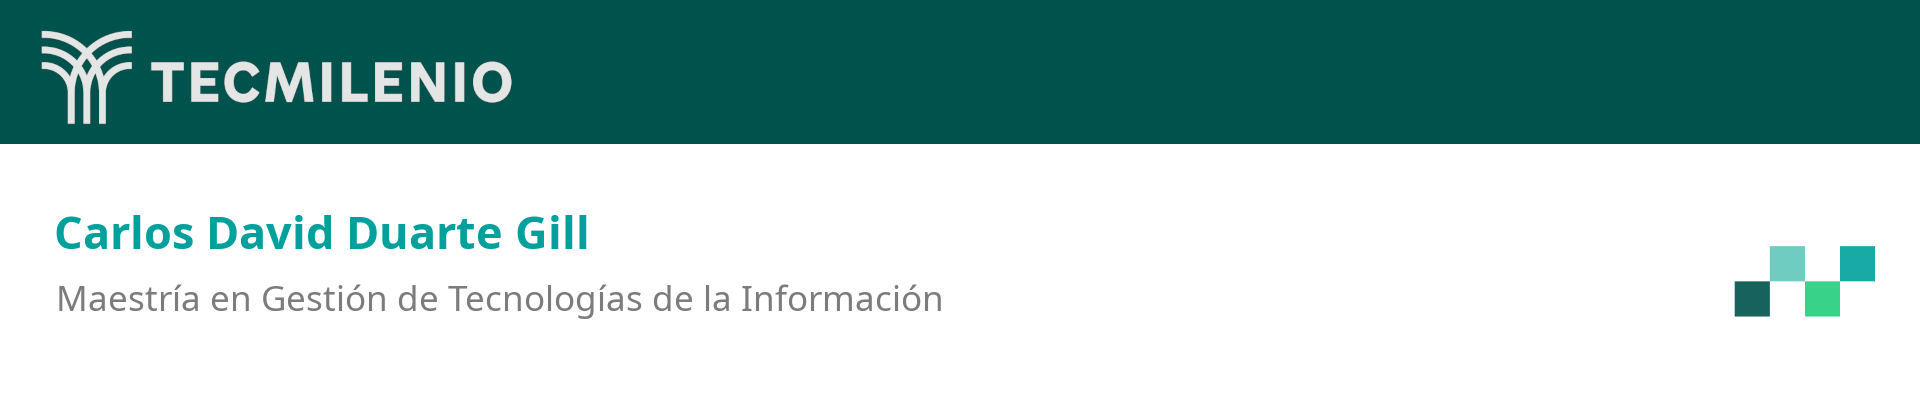

## **Aprendizaje automático y modelado predictivo**

- Alumno: Carlos David Duarte Gill
- Matricula: 7089642
- Correo: AL07089642@tecmilenio.mx
- Profesor: Fabiola Cristina Olguín Barrón
- Fecha:  jueves 23 de octubre de 2025

*Cursando la Maestría en Gestión de Tecnologías de la Información*

# 🔤 Introducción

En esta actividad se busca superar las limitaciones de la regresión lineal básica aplicando un pipeline de modelado avanzado en Python.

El objetivo es construir y comparar modelos de regresión lineal simple, múltiple, polinomial y regularizada; todo esto en base a un dataset de una compañía  de seguros, y, con el objetivo de determinar la relación precisa entre los factores de riesgo del cliente y el costo final del seguro, buscando el mejor balance entre el ajuste a los datos históricos y la capacidad de generalización.

## Alcance del análisis en la Actividad 2

El alcance de la actividad abarca los siguientes puntos clave:
1. Establecer el rendimiento de la Regresión Lineal Múltiple como punto de referencia.
2. Implementar la Regresión Polinomial para capturar relaciones no lineales y detectar sobreajuste.
3. Aplicar las técnicas de regularización Ridge y Lasso al modelo polinomial para mitigar el sobreajuste, simplificar el modelo y mejorar su rendimiento en datos de prueba.
4. Finalmente una evaluación final y comparar las métricas de todos los modelos para seleccionar la solución más óptima para el modelo.

# 📁 Carga el conjunto de datos en Python

Se sube el dataset **insurance.csv** a un repositorio público. El dataset se encuentra en: https://raw.githubusercontent.com/RamRider89/analisis-estadistico-exploratorio/refs/heads/main/insurance.csv


**A continuación:**

🧰 Se importan las librerías necesarias para el análisis y la visualización como numpy, scipy.stats, matplotlib.pyplot y seaborn, entre otras.

🔧 Se carga el dataset y se muestra una tabla descriptiva del dataset.

## 🧰 Carga de todas las librerías necesarias

In [ ]:
# cargando todas las librerías necesarias
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
# scales
from sklearn.preprocessing import MinMaxScaler
# labels categoricos
from sklearn.preprocessing import LabelEncoder
# segments
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
# regresion
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# logisticas
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
# multinomial
from sklearn.metrics import classification_report, confusion_matrix
# statsmodels
import statsmodels.api as sm
# ordinal
from statsmodels.miscmodels.ordinal_model import OrderedModel
# charts roc
from sklearn.metrics import roc_curve, auc
# polinomial
from sklearn.preprocessing import PolynomialFeatures
# sobreajuste
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
# warnings
import warnings
warnings.filterwarnings('ignore')

print("-" * 80)
print("Librerias importadas!")

--------------------------------------------------------------------------------
Librerias importadas!


**🔍 Revisar sección, Información de librerias utilizadas, para mayor detalle**

In [ ]:
# estilo de las graficas
sns.set_style("white")
# colores tecmilenio
_color_tecmi_light="#26d07c"
_color_tecmi_dark="#00534c"
_color_teal="#20c997"
# colores generales
_color_purple="#6f42c1"
_color_pink="#e83e8c"
_color_orange="#fd7e14"
# colores boostrap
_color_primary="#007bff"
_color_gray="#6c757d"
_color_danger="#ff0000"
_color_success="#28a745"
_color_info="#17a2b8"
_color_warning="#ffc107"
# tamaños de fuente
_fontsize_title = 16
_fontsize_label = 12
_fontsize_marker = 9
# paletas de colores prearmadas
_paleta_tecmi = [_color_tecmi_light, _color_purple, _color_warning, _color_info, _color_primary]
_paleta_secundaria = [_color_tecmi_light, _color_primary, _color_purple]

## 🌐 Carga del dataset desde URL pública

In [ ]:
# definimos la url del archivo csv
_URL_ = 'https://raw.githubusercontent.com/RamRider89/analisis-estadistico-exploratorio/refs/heads/main/insurance.csv'

# definiendo los nombres de las columnas del archivo
# age,sex,bmi,children,smoker,region,charges
_Age_ = 'age'
_Sex_ = 'sex'
_BMI_ = 'bmi'
_Children_ = 'children'
_Smoker_ = 'smoker'
_Region_ = 'region'
_Charges_ = 'charges'
_COLUMNAS_CSV_ = [_Age_, _Sex_, _BMI_, _Children_, _Smoker_, _Region_, _Charges_]

# config
pd.set_option('display.max_columns', None)

# leyendo el archivo csv mediante pandas
df = pd.read_csv(_URL_, usecols=_COLUMNAS_CSV_)

## 🔍 Información de la estructura del DataSet

In [ ]:
# definición de columnas por su tipo de estructura
_COLUMNAS_NUMERICAS_ = [_Age_, _BMI_, _Children_, _Charges_]
_COLUMNAS_CATEGORICAS_ = [_Sex_, _Smoker_, _Region_]

In [ ]:
print("-" * 80)
print("\033[1m --- Dataset cargado correctamente --- \033[0m")
print("-"*80)
print(f"Dataset shape: {df.shape}")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

--------------------------------------------------------------------------------
 --- Dataset cargado correctamente --- 
--------------------------------------------------------------------------------
Dataset shape: (1338, 7)
Número de filas: 1338
Número de columnas: 7


# 🩺 Diagnóstico y limpieza de registros mediante ETL

Se realiza un proceso sistemático de ETL para nuestro dataset, con el objetivo de limpieza y transformación de los datos.

## 🔍 Exploración inicial

In [ ]:
# --- Diagnóstico Inicial ---
print("-" * 80)
print("\033[1m --- Tipos de datos y nulos --- \033[0m")
print("-"*80)

print(df.info())

print("\n")
print("-" * 80)
print("\033[1m --- Estadísticas Descriptivas del Dataset --- \033[0m")
print("-"*80)

print(df.describe())

--------------------------------------------------------------------------------
 --- Tipos de datos y nulos --- 
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


--------------------------------------------------------------------------------
 --- Estadísticas Descriptivas del Dataset --- 
--------------------------------------------------------------------------------
               age          bmi     children       charges
count  13

El dataset no continene nulos, tampoco contiene valores negativos en las columnas numericas como edad. Se continua con el diagnóstico.

## 🔴 Detección y eliminación de duplicados

Se revisa si nuestro dataset **healthcare-dataset.csv** cuenta con registros duplicados, para ser eliminados y evitar que sesguen el análisis.

In [ ]:
print("-" * 80)
print("\033[1m --- Limpieza de registros duplicados: --- \033[0m")
print("-" * 80)
print(f"Número de filas antes de la limpieza: {df.shape[0]}")
# contamos los registros duplicados
total_duplicados = df.duplicated().sum()
print(f"Registros \033[1m duplicados encontrados: {total_duplicados}\033[0m")
# eliminamos duplicados y nos aseguramos de que df_limpio sea una copia explícita
df_limpio = df.drop_duplicates().copy()
# resultados
print("-" * 80)
print(f"\nNúmero de \033[1m filas después de la limpieza: {df_limpio.shape[0]}\033[0m")
print(f"Número de columnas después de la limpieza: \033[1m {df_limpio.shape[1]}\033[0m")

--------------------------------------------------------------------------------
 --- Limpieza de registros duplicados: --- 
--------------------------------------------------------------------------------
Número de filas antes de la limpieza: 1338
Registros  duplicados encontrados: 1
--------------------------------------------------------------------------------

Número de  filas después de la limpieza: 1337
Número de columnas después de la limpieza:  7


## ✅ Verificación de registros con valores negativos

Se realiza una búsqueda de valores negativos en las columnas numéricas como edad, bmi, hijos y cargos.
De acuerdo con la naturaleza del dataset, seria ilógico que algunos registros como edad o hijos contarán con registros negativos.

In [ ]:
print("-" * 80)
print("\033[1m --- Identificación de registros negativos --- \033[0m")
print("-" * 80)
# recorremos las columnas numericas
for col in _COLUMNAS_NUMERICAS_:
    # rev
    negativos = df_limpio[df_limpio[col] < 0]
    # mensaje
    print(f"Columna \033[1m { col } \033[0m con {len(negativos)} valores negativos")

--------------------------------------------------------------------------------
 --- Identificación de registros negativos --- 
--------------------------------------------------------------------------------
Columna  age  con 0 valores negativos
Columna  bmi  con 0 valores negativos
Columna  children  con 0 valores negativos
Columna  charges  con 0 valores negativos


El dataset no cuenta con valores negativos en las columnas numericas. De esta manera nos aseguramos que los análisis y predicciones se basen únicamente en datos válidos y lógicos.

## ✅ Verificación de valores nulos

A continuación, identificaremos los valores nulos en el dataset y aplicaremos una estrategia de imputación para rellenar valores faltantes.

In [ ]:
print("-" * 80)
print("\033[1m --- Valores nulos por columna: --- \033[0m")
print("-" * 80)
# contamos todos los valores nulos de todas las columnas
nulos_por_columna = df_limpio.isnull().sum().reset_index()

# rajuste para mostrar los valores nulos como tabla
nulos_por_columna.columns=['Columna', 'Nulos']
print(nulos_por_columna.sort_values(by='Nulos', ascending=False))

--------------------------------------------------------------------------------
 --- Valores nulos por columna: --- 
--------------------------------------------------------------------------------
    Columna  Nulos
0       age      0
1       sex      0
2       bmi      0
3  children      0
4    smoker      0
5    region      0
6   charges      0


Se confirma la precencia de cero valores nulos en el dataset.

## ✅ Verificación de valores únicos en columnas categóricas

In [ ]:
# en base a nuestras columnas categoricas: _Sex_, _Smoker_, _Region_
columnas_categoricas = df_limpio[_COLUMNAS_CATEGORICAS_]
# definimos el diccionario de valores unicos
_dict_unique_values_ = {
    _Sex_: [],
    _Smoker_: [],
    _Region_: []
}

# recorremos las columnas categoricas para obtener sus valores
print("-" * 80)
print("\033[1m --- Valores únicos por columna categórica: --- \033[0m")
print("-" * 80)
for col in columnas_categoricas.columns:
    # obtenemos los vals unicos
    unique_values = columnas_categoricas[col].unique()
    # asignamos los valores unicos al dict
    _dict_unique_values_[col] = columnas_categoricas[col].unique()

# para mostrar el resultado del diccionario en pantalla
# convertimos el diccionario a un conjunto de listas
data = [[key] + list(value) for key, value in _dict_unique_values_.items()]

# definimos los titulos de la tabla
headers = ["Columna"] + [f"Valor único {i+1}" for i in range(len(max(_dict_unique_values_.values(), key=len)))]
# imprimiendo
print(tabulate(data, headers=headers, tablefmt="grid"))


--------------------------------------------------------------------------------
 --- Valores únicos por columna categórica: --- 
--------------------------------------------------------------------------------
+-----------+-----------------+-----------------+-----------------+-----------------+
| Columna   | Valor único 1   | Valor único 2   | Valor único 3   | Valor único 4   |
+===========+=================+=================+=================+=================+
| sex       | female          | male            |                 |                 |
+-----------+-----------------+-----------------+-----------------+-----------------+
| smoker    | yes             | no              |                 |                 |
+-----------+-----------------+-----------------+-----------------+-----------------+
| region    | southwest       | southeast       | northwest       | northeast       |
+-----------+-----------------+-----------------+-----------------+-----------------+


De esta manera hemos comprobado los valores únicos de nuestras columnas categóricas, mismo que ya están limpios y sin valores nulos.

## ⚙️ Transformación y Normalización de Variables

A continuación, se procederá a transformar las variables para hacerlas útiles para el análisis y modelado.

### ✔ 1. Codificación de variables categóricas

Los modelos de machine learning no pueden procesar variables categóricas como Fumador directamente, es por ello que realizaremos una recodificación automática a un formato numérico, lo cual es esencial para el modelado.

In [ ]:
# Codificación de variables categóricas (sex, smoker, region)
# inicializamos el codificador Label Encoding
le = LabelEncoder()

# nuevas columnas
_Sex_Encoded_ = _Sex_ + '_encoded'
_Smoker_Encoded_ = _Smoker_ + '_encoded'
_Region_Encoded_ = _Region_ + '_encoded'

# aplicamos un label Encoding a la columna 'sex'
df_limpio.loc[:, _Sex_Encoded_] = le.fit_transform(df_limpio.loc[:, _Sex_])

# aplicamos un label Encoding a la columna 'smoker'
df_limpio.loc[:, _Smoker_Encoded_] = le.fit_transform(df_limpio.loc[:, _Smoker_])

# aplicamos un label Encoding a la columna 'region'
df_limpio.loc[:, _Region_Encoded_] = le.fit_transform(df_limpio.loc[:, _Region_])


#### Resultado de la codificación

In [ ]:
# sex
_dicts_encoded = {}
_dicts_encoded[_Sex_] = {
    _Sex_: df_limpio[_Sex_].unique(),
    _Sex_Encoded_: df_limpio[_Sex_Encoded_].unique()
}

# smoker
_dicts_encoded[_Smoker_] = {
    _Smoker_: df_limpio[_Smoker_].unique(),
    _Smoker_Encoded_: df_limpio[_Smoker_Encoded_].unique()
}

# regiones
_dicts_encoded[_Region_] = {
    _Region_: df_limpio[_Region_].unique(),
    _Region_Encoded_: df_limpio[_Region_Encoded_].unique()
}

for col in _COLUMNAS_CATEGORICAS_:
    # para mostrar el resultado del diccionario en pantalla
    # convertimos el diccionario a un conjunto de listas
    data = [[key] + list(value) for key, value in _dicts_encoded[col].items()]

    # definimos los titulos de la tabla
    headers = ["Columna"] + [f"Valor único {i+1}" for i in range(len(max(_dicts_encoded[col].values(), key=len)))]

    # imprimiendo
    print("\n")
    print("-" * 80)
    print(f"\033[1m --- Columna: {col} - Recodificación de variables categóricas --- \033[0m")
    print("-" * 80)
    print(tabulate(data, headers=headers, tablefmt="grid"))



--------------------------------------------------------------------------------
 --- Columna: sex - Recodificación de variables categóricas --- 
--------------------------------------------------------------------------------
+-------------+-----------------+-----------------+
| Columna     | Valor único 1   | Valor único 2   |
+=============+=================+=================+
| sex         | female          | male            |
+-------------+-----------------+-----------------+
| sex_encoded | 0               | 1               |
+-------------+-----------------+-----------------+


--------------------------------------------------------------------------------
 --- Columna: smoker - Recodificación de variables categóricas --- 
--------------------------------------------------------------------------------
+----------------+-----------------+-----------------+
| Columna        | Valor único 1   | Valor único 2   |
+================+=================+=================+
| smoker  

Recodificación completa

### ✔ 2. Codificación geográfica de regiones 🌎

A partir de la codificación anterior, donde Label Encoder genera una codificación del 0 al 3 para las cuatro regiones, he decidido crear una nueva codificación por atributos de las regiones, en orden con su proximidad geográfica.

Diviendo la ubicación en 4 simples cuadrantes, tendremos:
- Norte, con un valor de 1
- Sur, con un valor de 0
- Este, con un valor de 1
- Oeste, con un valor de 0

De esta manera, transformamos la variable región en dos variables binarias independientes que tienen un significado físico Norte/Sur, Este/Oeste.  

Considero que esto permitirá al modelo aprender si el costo del seguro está más influenciado por un factor geográfico.

In [ ]:
# mejora de codificacion: Codificación geográfica de regiones
# se crean de las dos nuevas variables binarias a partir de la columna _Region_

# nuevas columnas
_is_north_south_encoded_ = 'is_north_south' + '_encoded'
_is_west_east_encoded_ = 'is_west_east' + '_encoded'

# col: is_north_south, donde: 1 para norte, 0 para sur
df_limpio[_is_north_south_encoded_] = np.where(df_limpio[_Region_].str.contains('north'), 1, 0)

# col: is_west_east, donde:1 para este, 0 para oeste
df_limpio[_is_west_east_encoded_] = np.where(df_limpio[_Region_].str.contains('east'), 1, 0)

In [ ]:
# validamos la codificación
_dict_unique_region_values_ = {
    _Region_: df_limpio.groupby(_Region_)[_Region_].first().values,
    _is_north_south_encoded_: df_limpio.groupby(_Region_)[_is_north_south_encoded_].first().values,
    _is_west_east_encoded_: df_limpio.groupby(_Region_)[_is_west_east_encoded_].first().values
}

# --- visualización de la recodificación ---
data = [[key] + list(value) for key, value in _dict_unique_region_values_.items()]
headers = ["Columna"] + [f"Valor unico {i+1}" for i in range(len(max(_dict_unique_region_values_.values(), key=len)))]

print("-" * 80)
print("\033[1m--- Recodificación de Variables Categóricas Geográficas ---\033[0m")
print("-" * 80)
print(tabulate(data, tablefmt="grid"))

--------------------------------------------------------------------------------
--- Recodificación de Variables Categóricas Geográficas ---
--------------------------------------------------------------------------------
+------------------------+-----------+-----------+-----------+-----------+
| region                 | northeast | northwest | southeast | southwest |
+------------------------+-----------+-----------+-----------+-----------+
| is_north_south_encoded | 1         | 1         | 0         | 0         |
+------------------------+-----------+-----------+-----------+-----------+
| is_west_east_encoded   | 1         | 0         | 1         | 0         |
+------------------------+-----------+-----------+-----------+-----------+


In [ ]:
# comentarios
'''
- Norte, con un valor de 1
- Sur, con un valor de 0
- Este, con un valor de 1
- Oeste, con un valor de 0
'''

'\n- Norte, con un valor de 1\n- Sur, con un valor de 0\n- Este, con un valor de 1\n- Oeste, con un valor de 0\n'

Hecho esto, nuestras variables están mejor codificadas y hemos creados dos nuevas variables geográficas.

### ✔ 3. Estandarización de variables numéricas

Las variables **Edad, BMI, e Hijos** serán normalizadas para evitar que afecten negativamente a los modelos de aprendizaje.

La normalización escalará los valores a un rango entre, lo que asegurará que todos los datos tengan el mismo peso en el análisis.

Estas variables serán consideradas como parte de las variables independientes, por otro lado, nuestra variable objetivo **Charges** no será normalizada. Mantendrá su escala original para que el MAE y los coeficientes sean directamente interpretables en términos monetarios reales.

In [ ]:
# eliminamos las columnas de texto originales y la columna 'region' original
X = df_limpio.drop(['charges', 'sex', 'smoker', 'region'], axis=1).copy()
# variable objetivo: charges
y = df_limpio['charges'].copy()

# división en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# estandarización de variables numéricas
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# se escala solo las variables numericas independientes
cols_to_scale = ['age', 'bmi', 'children']
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("-" * 80)
print("\033[1m---- Preparación de datos completada ---\033[0m")
print("-" * 80)

--------------------------------------------------------------------------------
---- Preparación de datos completada ---
--------------------------------------------------------------------------------


Al momento nos hemos asegurado de tener un dataset limpio y libre de registros nulos y duplicados, a su vez, se han realizado tres transformaciones:
1. **Codificación de variables categóricas**
2. **Codificación geográfica de regiones**
3. **Estandarización de variables numéricas**

Además de agregar las nuevas columnas para la codificación geográfica:
- is_north_south_encoded
- is_west_east_encoded

Con estas transformaciones, nuestro dataset está limpio y enriquecido.

In [ ]:
X_train_scaled.head()

,age,bmi,children,sex_encoded,smoker_encoded,region_encoded,is_north_south_encoded,is_west_east_encoded
1114,-1.157680,-0.996928,-0.907908,1,0,0,1,1
968,-1.300619,-0.792762,0.766904,1,0,0,1,1
599,0.914926,1.154664,0.766904,0,0,1,1,0
170,1.701087,1.806837,-0.907908,1,0,2,0,1
275,0.557580,-0.651417,0.766904,0,0,0,1,1


## ✔ Estructura del Dataset limpio

In [ ]:
print("-" * 80)
print("\033[1m --- Dataset limpiado correctamente --- \033[0m")
print("-" * 80)
print(f"Número de filas: {df_limpio.shape[0]}")
print(f"Número de columnas: {df_limpio.shape[1]}")

--------------------------------------------------------------------------------
 --- Dataset limpiado correctamente --- 
--------------------------------------------------------------------------------
Número de filas: 1337
Número de columnas: 12


In [ ]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     1337 non-null   int64  
 1   sex                     1337 non-null   object 
 2   bmi                     1337 non-null   float64
 3   children                1337 non-null   int64  
 4   smoker                  1337 non-null   object 
 5   region                  1337 non-null   object 
 6   charges                 1337 non-null   float64
 7   sex_encoded             1337 non-null   int64  
 8   smoker_encoded          1337 non-null   int64  
 9   region_encoded          1337 non-null   int64  
 10  is_north_south_encoded  1337 non-null   int64  
 11  is_west_east_encoded    1337 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 135.8+ KB


In [ ]:
df_limpio.describe()

,age,bmi,children,charges,sex_encoded,smoker_encoded,region_encoded,is_north_south_encoded,is_west_east_encoded
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487,0.504862,0.204936,1.516081,0.484667,0.514585
std,14.044333,6.100468,1.205571,12110.359656,0.500163,0.403806,1.105208,0.499952,0.499974
min,18.000000,15.960000,0.000000,1121.873900,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,26.290000,0.000000,4746.344000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,39.000000,30.400000,1.000000,9386.161300,1.000000,0.000000,2.000000,0.000000,1.000000
75%,51.000000,34.700000,2.000000,16657.717450,1.000000,0.000000,2.000000,1.000000,1.000000
max,64.000000,53.130000,5.000000,63770.428010,1.000000,1.000000,3.000000,1.000000,1.000000


In [ ]:
df_limpio.head()

,age,sex,bmi,children,smoker,region,charges,sex_encoded,smoker_encoded,region_encoded,is_north_south_encoded,is_west_east_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,0,1,3,0,0
1,18,male,33.770,1,no,southeast,1725.55230,1,0,2,0,1
2,28,male,33.000,3,no,southeast,4449.46200,1,0,2,0,1
3,33,male,22.705,0,no,northwest,21984.47061,1,0,1,1,0
4,32,male,28.880,0,no,northwest,3866.85520,1,0,1,1,0


## 🗂 Resumen de la estructura del Dataset limpio

| Nombre de Columna			| Tipo de dato  | Rango / Valores únicos    												| Descripción
|---------------------------|---------------|---------------------------------------------------------------------------|---------------------------------------|
| Age 						| int64 		| De 18 a 64 																| Edad del asegurado. 					|
| Sex	 					| object 		| [male, female]	 														| Género del asegurado. 				|
| BMI		 				| float64 		| De 15.96 a 53.1337														| Índice de Masa Corporal				|
| Children 					| int64 		| De 0 a 5 																	| Número de hijos				 		|
| Smoker 					| object 		| 1337 registros de tipo [yes, no]											| Condicion de fumador (si o no)		|
| Region 					| object 		| [southwest | southeast | northwest | northeast ]							| Ubicación geográfica del asegurado	|
| Charges 					| float64 		| 1337 registros  															| Costos, variable objetivo.	 		|
| sex_encoded 				| int64 		| 1337 registros 															| Género del asegurado (encoded). 		|
| smoker_encoded			| int64 		| 1337 registros 															| Condicion de fumador (encoded). 		|
| region_encoded 			| int64 		| 1337 registros 															| Ubicación geográfica(encoded). 		|
| is_north_south_encoded 	| int64 		| 1337 registros 															| Norte/Sur geográfico (encoded). 		|
| is_west_east_encoded 		| int64 		| 1337 registros 															| Este/Oeste geográfico (encoded). 		|

A partir del proceso de limpieza y transformación aplicado, el dataset es ahora más confiable para los procesos de aprendizaje.

# 💻 Análisis Exploratorio de Datos (EDA).

Ahora que nuestro dataset está limpio y preparado, podemos pasar por la fase de Análisis Exploratorio de Datos. Aquí se incluirán algunas visualizaciones clave para descubrir patrones, tendencias y anomalías relevantes antes de pasar a la creación de los modelos de regresión.

La visualización de la distribución de las variables principales nos ayudará a entender la estructura de los datos y justificar las próximas decisiones para los modelos.

## 📊 Visualización 1: Distribución de edades

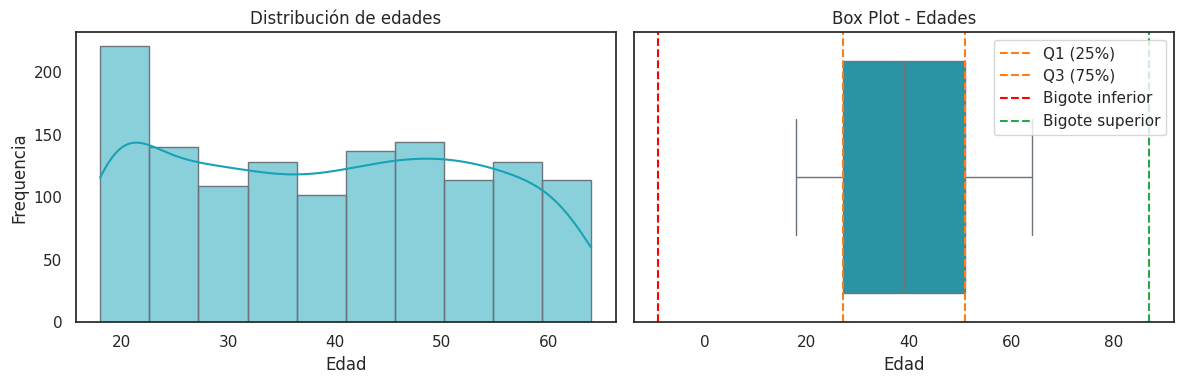

--------------------------------------------------------------------------------
 --- Estadisticas por edad --- 
--------------------------------------------------------------------------------
┌────────┬───────┬───────┬──────┬──────┬──────┬──────┬──────┐
│ count  │ mean  │ std   │ min  │ 25%  │ 50%  │ 75%  │ max  │
├────────┼───────┼───────┼──────┼──────┼──────┼──────┼──────┤
│ 1337.0 │ 39.22 │ 14.04 │ 18.0 │ 27.0 │ 39.0 │ 51.0 │ 64.0 │
└────────┴───────┴───────┴──────┴──────┴──────┴──────┴──────┘


In [ ]:
# iniciamos el plot y area de impresión
plt.figure(figsize=(12, 4))
# subplot uno para histograma
plt1 = plt.subplot(1, 2, 1)
# histograma
at = sns.histplot(
    data=df_limpio,
    x=_Age_,
    color=_color_info,
    edgecolor=_color_gray,
    bins=10,
    kde=True,
    shrink=1
)
# titulos
plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Frequencia')
# ------------------------------------------------------------------------------

# plot dos para boxplot
plt2 = plt.subplot(1, 2, 2)

# boxplot
ax2 = sns.boxplot(
    x=df_limpio[_Age_],
    color=_color_info,
    linecolor=_color_gray
)

# calculamos valores estadísticos
q1 = df_limpio[_Age_].quantile(0.25)
q3 = df_limpio[_Age_].quantile(0.75)
iqr = q3 - q1
lower_whisker = q1 - 1.5 * iqr
upper_whisker = q3 + 1.5 * iqr

# anotaciones y limites
plt2.axvline(q1, color=_color_orange, linestyle="--", label="Q1 (25%)")
plt2.axvline(q3, color=_color_orange, linestyle="--", label="Q3 (75%)")
plt2.axvline(lower_whisker, color=_color_danger, linestyle="--", label="Bigote inferior")
plt2.axvline(upper_whisker, color=_color_success, linestyle="--", label="Bigote superior")
# titulos
plt.title('Box Plot - Edades')
plt.xlabel('Edad')
# show
plt.tight_layout()
plt.legend()
plt.show()
# ------------------------------------------------------------------------------
# información general
print("-" * 80)
print("\033[1m --- Estadisticas por edad --- \033[0m")
print("-" * 80)
# imprimimos las estadisticas de edad utilizando el formato de 'tabulate'
print(tabulate(
    df_limpio[_Age_].describe().round(decimals=2).reset_index().transpose(),
    tablefmt="simple_grid",
    showindex="never",
    )
)

### 📑 Interpretación

**Análisis de la Distribución de Edades**

- La distribución de edades es bastante uniforme, aunque se observan ligera dominancia en los rangos de edad alrededor de los 20, 40 y 60 años.
- La curva de densidad sugiere que no hay un sesgo significativo ni a la juventud ni a la vejez. La población de clientes parece tener una representación relativamente equitativa en todas las edades, desde los 18 hasta los 64 años.
- El boxplot confirma la uniformidad del histograma. La caja del boxplot está centrada en la mediana, indicando una distribución simétrica.
- Lo más importante para el diseño de modelos: el gráfico no muestra la presencia de valores atípicos, por lo que no es necesario aplicar técnicas de tratamiento de outliers como la imputación por IQR.

La variable Age paraece estar limpia y bien balanceada, lo que la convierte en un predictor confiable para nuestros modelos de Regresión Lineal y Regresión Logística.

## 📊 Visualización 2: Distribución por variables categóricas

Se generán las gráficas para la distribución de las variables categoricas: genero, fumadores y regiones.

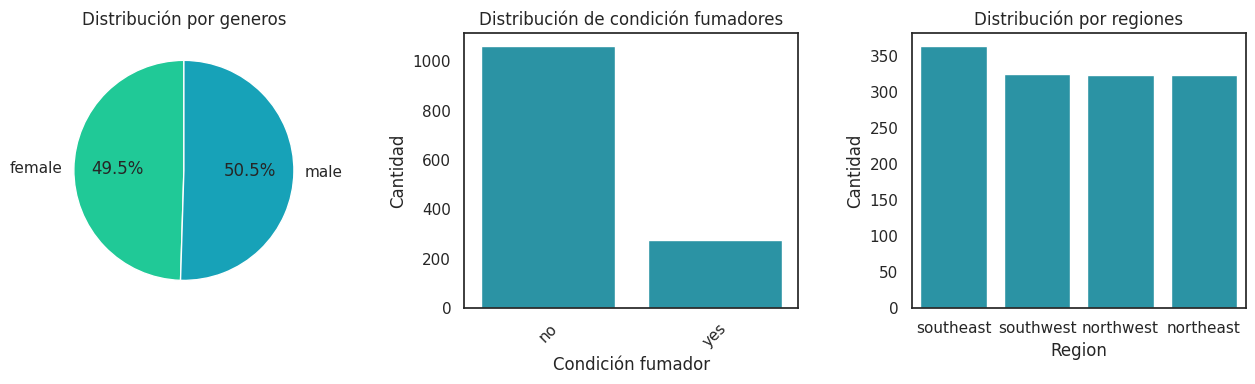

In [ ]:
# graficas categoricas
plt.figure(figsize=(13, 4))
# ------------------------------------------------------------------------------
# subplot para distribucion de generos
plt.subplot(1, 3, 1)

# agrupando los datos por Genero para contar la cantidad de registros en cada grupo
count_genders = df_limpio.groupby([_Sex_]).size().reset_index(name='Cantidad')
# configurando el grafico circular
plt.pie(
    count_genders['Cantidad'],
    labels=count_genders[_Sex_],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette([_color_teal, _color_info]))

# titulos
plt.title('Distribución por generos')

# ------------------------------------------------------------------------------
# subplot para distribucion de condicion de fumador
plt.subplot(1, 3, 2)
# agrupacion y conteo de fumadores
count_data = df_limpio.groupby([_Smoker_]).size().reset_index(name='Cantidad')
x_data = count_data[_Smoker_]
y_data = count_data['Cantidad']
# creando la grafica de barras
ax = sns.barplot(
    data=count_data,
    x=x_data,
    y=y_data,
    color=_color_info)

# titulos
plt.title('Distribución de condición fumadores')
plt.xlabel('Condición fumador')
plt.ylabel('Cantidad')
plt.xticks(
    range(len(x_data)),
    x_data,
    rotation=45)

# ------------------------------------------------------------------------------
# subplot para distribucion de regiones
plt.subplot(1, 3, 3)

# agrupacion y conteo de regiones
count_data = df_limpio[_Region_].value_counts().reset_index()
x_data = count_data[_Region_]
y_data = count_data['count']
# creando la grafica de barras
ax = sns.barplot(
    data=count_data,
    x=x_data,
    y=y_data,
    color=_color_info)

# titulos
plt.title('Distribución por regiones')
plt.xlabel('Region')
plt.ylabel('Cantidad')

# ------------------------------------------------------------------------------
# show
plt.tight_layout()
plt.show()




### 📑 Interpretación

**Análisis de la Distribución de Variables Categóricas**


En cuanto a la distribución por **Géneros**:

- El gráfico circular indica una distribución casi perfectamente equilibrada: 50.5% hombres y 49.5% mujeres.
- Gracias a este dato, sabemos que el modelo no estará sesgado hacia un género por tener un tamaño de muestra mayor.

En cuanto a la distribución de **Condición Fumadores**:

- El gráfico de barras muestra una distribución fuertemente desequilibrada: la gran mayoría de los clientes son No fumadores frente a un grupo minoritario de Si Fumadores.
- Esta variable se alinea con la realidad y podría convertirse en el predictor más importante para los modelos.

En cuanto a la distribución por **Regiones**:

- El gráfico de barras muestra que las cuatro regiones y están representadas de manera uniforme y equilibrada. No se aprecia alguna región predominante que puediese afectar en las prubas de los modelos.

## 📊 Visualización 3: Distribución del costo (charges)

Se analizará la distribución de la variable charges para entender su estructura, posibles sesgos y la presencia de valores atípicos.

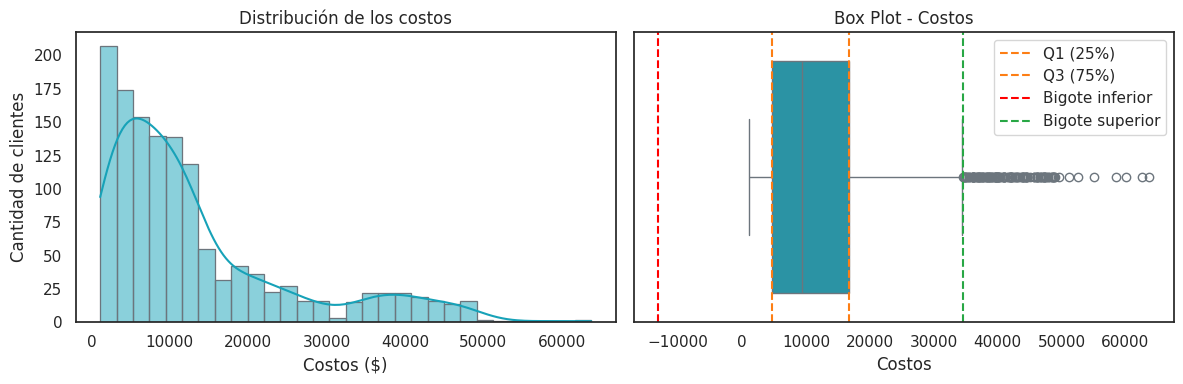

--------------------------------------------------------------------------------
 --- Estadisticas de costos (charges) --- 
--------------------------------------------------------------------------------
┌────────┬──────────┬──────────┬─────────┬─────────┬─────────┬──────────┬──────────┐
│ count  │ mean     │ std      │ min     │ 25%     │ 50%     │ 75%      │ max      │
├────────┼──────────┼──────────┼─────────┼─────────┼─────────┼──────────┼──────────┤
│ 1337.0 │ 13279.12 │ 12110.36 │ 1121.87 │ 4746.34 │ 9386.16 │ 16657.72 │ 63770.43 │
└────────┴──────────┴──────────┴─────────┴─────────┴─────────┴──────────┴──────────┘


In [ ]:
# costos
costos = df_limpio[_Charges_].copy()

# iniciamos el plot y area de impresión
plt.figure(figsize=(12, 4))
# subplot uno para histograma
plt1 = plt.subplot(1, 2, 1)
# histograma
at = sns.histplot(
    x=costos,
    color=_color_info,
    edgecolor=_color_gray,
    bins=30,
    kde=True,
    shrink=1
)
# titulos
plt.title('Distribución de los costos')
plt.xlabel('Costos ($)')
plt.ylabel('Cantidad de clientes')

# ------------------------------------------------------------------------------
# plot dos para boxplot
plt2 = plt.subplot(1, 2, 2)

# boxplot
ax2 = sns.boxplot(
    x=costos,
    color=_color_info,
    linecolor=_color_gray
)

# calculamos valores estadísticos
q1 = costos.quantile(0.25)
q3 = costos.quantile(0.75)
iqr = q3 - q1
lower_whisker = q1 - 1.5 * iqr
upper_whisker = q3 + 1.5 * iqr

# anotaciones y limites
plt2.axvline(q1, color=_color_orange, linestyle="--", label="Q1 (25%)")
plt2.axvline(q3, color=_color_orange, linestyle="--", label="Q3 (75%)")
plt2.axvline(lower_whisker, color=_color_danger, linestyle="--", label="Bigote inferior")
plt2.axvline(upper_whisker, color=_color_success, linestyle="--", label="Bigote superior")
# titulos
plt.title('Box Plot - Costos')
plt.xlabel('Costos')
# show
plt.tight_layout()
plt.legend()
plt.show()

# ------------------------------------------------------------------------------
# información general
print("-" * 80)
print("\033[1m --- Estadisticas de costos (charges) --- \033[0m")
print("-" * 80)
# imprimimos las estadisticas de edad utilizando el formato de 'tabulate'
print(tabulate(
    costos.describe().round(decimals=2).reset_index().transpose(),
    tablefmt="simple_grid",
    showindex="never",
    )
)

### 📑 Interpretación

**Análisis de la distribución del costo**

- De acuerdo con el histograma, la distribución de los costos es fuertemente sesgada a la derecha y la gran mayoría de los clientes se concentran en el rango de costos más bajos, entre 0 y 10 mil pesos.
- Hay una larga lista de clientes que representan costos más altos, arriba de los 40,000 y hasta un poco más de 60,000 pesos, pero con una frecuencia muy baja.
- Este comportamiento esta alineado con realidad de los costos, y se confirma que la mayoría de los eventos son de bajo costo, pero el riesgo financiero de la aseguradora está concentrado en una minoría de casos de alto costo.


- En cuanto al Box Plot, la caja principal es muy estrecha, concentrando el 50% central de los clientes en el rango de bajos costos.
- Además, el gráfico muestra una gran cantidad de valores atípicos, representados por los puntos grises que se extienden más allá del bigote superior, estos datos representan los casos de costos más altos.
- Esta distribución sesgada y la presencia de outliers podrián probocar un bajo desempeño de una Regresión Lineal, ya que tendrá dificultades para ajustarse a los casos de la lista de alto costo.

## 📊 Visualización 4: Costo promedio por tabaquismo

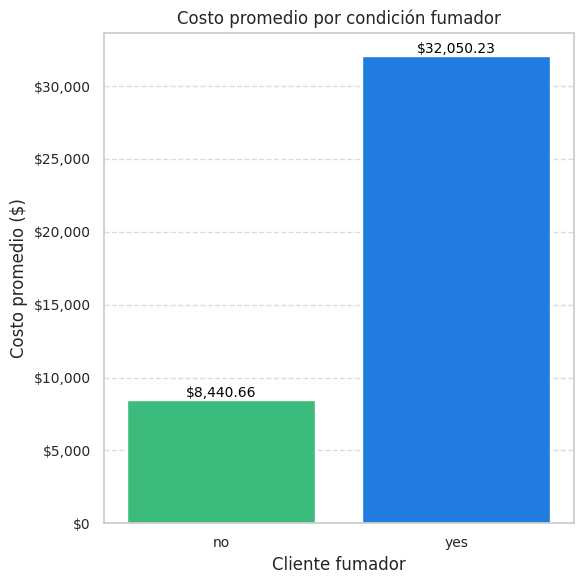

In [ ]:
# costo promedio por tabaquismo
costo_promedio_por_tabaquismo = df_limpio.groupby('smoker').agg(
    Costo_Promedio=('charges', 'mean')
).reset_index()

# gráfico de barras
plt.figure(figsize=(6, 6))

sns.barplot(
    x='smoker',
    y='Costo_Promedio',
    data=costo_promedio_por_tabaquismo,
    palette=_paleta_secundaria)

# etiquetas y título
plt.title('Costo promedio por condición fumador')
plt.xlabel('Cliente fumador')
plt.ylabel('Costo promedio ($)')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# eje Y como moneda
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# valores en las barras
for index, row in costo_promedio_por_tabaquismo.iterrows():
    plt.text(index, row['Costo_Promedio'], f'${row["Costo_Promedio"]:,.2f}',
             color='black', ha="center", va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

La comparación de los promedios es más que clara, los clientes fumadores conyevan un mayor costo médico con un promedio de $32,050 pesos.

## 📓 Resumen del EDA prevío

El **análisis exploratorio de datos** del conjunto de seguros muestra una estructura de datos balanceada pero con un sesgo en los datos de costos.

- Las variables **edad, sexo y región** están bien balanceadas, sin sesgos muestrales significativos. Esto las convierte en predictores estables para los siguientes modelos.

- En cuanto a la variable **smoker** está fuertemente desequilibrada hacia una población, con los fumadores representando una minoría de alto impacto. Con lo que se confirma que el tabaquismo puede ser un factor de cambio importante para los costos.

- Por otra parte, en la distribución del **costo**, se muestra claramente a una gran concentración de clientes en el rango de bajo costo y una larga lista de casos de alto costo, que serían los valores atipicos.


En resumen, por una parte tenemos una estabilidad en las variables independientes, y solo se identifican sesgos o variaciones importantes en la condicion del fumador y en el costo del seguro.

# 🆎 Modelado con regresión lineal

A continuación, se desarrollan diferentes modelos de regresión lineal para describir la relación entre las variable objetivo (Costos) y una o más variables independientes.

El objetivo será encontrar una línea recta que se ajuste mejor a los datos, permitiendo predecir el valor de una variable en función de otra.

Para el cálculo de regresiones, he decido utilizar **sklearn**, el cual está diseñado para el Machine Learning.

## 🤖 Regresión lineal simple

Primeramente, se aplica un modelo de regresión lineal simple, usando como variable dependiente charges y como variable independiente el bmi.

### ⚙ Cálculo

In [ ]:
# ------------------------------------------------------------------------------
# regresion simple: predicción con solo BMI
# ------------------------------------------------------------------------------

# seleccionamos y reajustamos los datos para la regresion
'''
Recordemos que en paso de normalizacion escalamos las variables independientes
'''
# datos de entrenamiento previos
X_train_simple = X_train_scaled[[_BMI_]]
X_test_simple = X_test_scaled[[_BMI_]]

# ------------------------------------------------------------------------------
# regresion simple
model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train)
y_pred_simple = model_simple.predict(X_test_simple)

# ------------------------------------------------------------------------------
# evaluacion
r2_simple = r2_score(y_test, y_pred_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)

# ------------------------------------------------------------------------------
# resultados
print("-" * 80)
print("\033[1m --- Regresión lineal simple con BMI --- \033[0m")
print("-" * 80)
print(f"Coeficiente (Impacto de BMI): {model_simple.coef_[0]:.2f}")
print(f"R² (Varianza explicada): {r2_simple:.4f}")
print(f"MAE (Error promedio): ${mae_simple:,.2f} pesos")
print(f"MSE: {mse_simple:,.2f}")

--------------------------------------------------------------------------------
 --- Regresión lineal simple con BMI --- 
--------------------------------------------------------------------------------
Coeficiente (Impacto de BMI): 2087.94
R² (Varianza explicada): 0.0517
MAE (Error promedio): $9,891.12 pesos
MSE: 174,251,720.52


### 📑 Interpretación

El modelo de regresión lineal simple, utilizando únicamente el BMI para predecir el costo del seguro, arroja las siguientes conclusiones:
- El coeficiente de determinación ($\text{R}^2$) es de 0.0517. Esto significa que el BMI por sí solo, explica el 5.17% de la variabilidad total en el costo del seguro. Y más del 94% restante del costo es definido por variables no incluidos en este modelo simple.
- El error absoluto medio (MAE) es de 9,891 pesos. Esto indica que, en promedio, la predicción de costos, basada únicamente en el BMI, se equivocará en casi 10 mil pesos. Considero que este nivel de error podrá resultar inaceptable para la administración de la aseguradora.

Esta regresión nos indica que el BMI es un factor de riesgo positivo, pero es insuficiente como predictor, ya que es muy poco lo que predice.

### 📉 Visualizacion

A continuación, para mejor interpretación, se muestra una grafica de la regresión lineal simple.

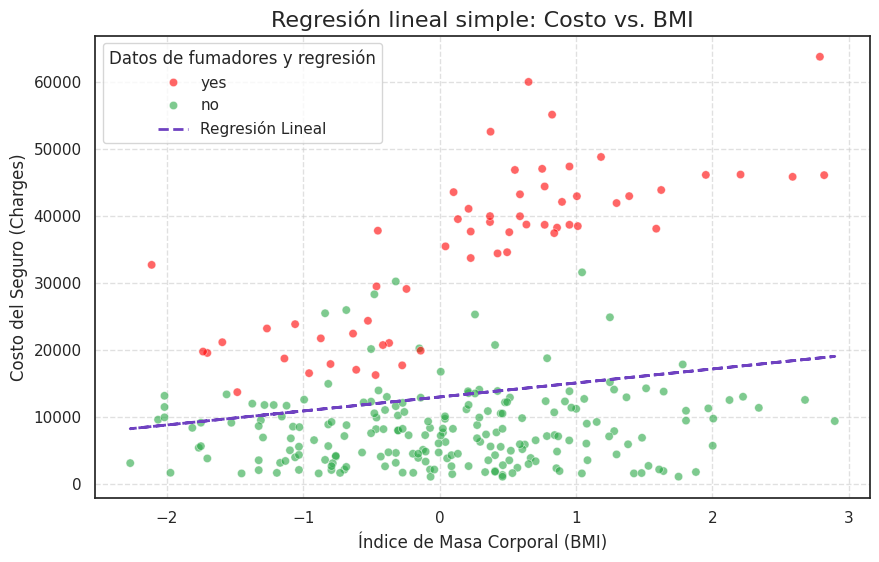

In [ ]:
# visualización de la regresion
# datos originales del BMI del conjunto de prueba

# BMI en base a los datos del set de prueba
bmi_original_test = X_test_scaled[_BMI_]
# obtenemos la variable original fumador para diferenciar el scatterplot
fumador_original = df_limpio['smoker']

# ------------------------------------------------------------------------------
# grafica
plt.figure(figsize=(10, 6))

# ------------------------------------------------------------------------------
'''
Para la nube de puntos
se utilizan las variables de entrenamiento del bmi
y se le da color para identificar a los grupos fumadores
'''
# nube de puntos con datos reales y diferenciados por la variable fumador
sns.scatterplot(x=bmi_original_test,
                y=y_test,
                hue=fumador_original,
                alpha=0.6,
                palette={'no': _color_success, 'yes': _color_danger}, # asignamos colores a los fumadores
                )

# ------------------------------------------------------------------------------
'''
Para la linea de regresion
se utilizan las variables de entrenamiento calculadas en el paso anterior:
X_test_simple
y_pred_simple
'''
# linea de regresión ajustada con las variables de entrenamiento
plt.plot(
    X_test_simple,
    y_pred_simple,
    color=_color_purple,
    linestyle='--',
    linewidth=2,
    label='Regresión Lineal'
)

# ------------------------------------------------------------------------------
# titulos
plt.title('Regresión lineal simple: Costo vs. BMI', fontsize=16)
plt.xlabel('Índice de Masa Corporal (BMI)', fontsize=12)
plt.ylabel('Costo del Seguro (Charges)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Datos de fumadores y regresión")
plt.xlim()
plt.show()

La gráfica valida la interpretación que realizamos sobre los resultados del modelo: esta regresión simple es poco útil para generar una predicción precisa. El modelo está siendo fuertemente afectado por otras variables y se nota en la disperción de los valores punteados.

Esta gráfica nos ayuda a identificar algunas pistas:
- Los datos de personas fumadoras se ubican en la parte superior de la gráfica, con costos que inician alrededor de 22,000 y se extienden hasta 60,000, y más.
- En cambio, los de no fumadores, se agrupan en la parte inferior, con la gran mayoría de los costos por debajo de 20,000.
- Definitivamente el costo del seguro no es impulsado por el BMI, sino por otras variables, incluidas el tabaquismo.

## 🤖 Regresión lineal multiple

Continuamos con el desarrollo de un modelo de regresión lineal múltiple, utilizando al menos 4 variables independientes relevantes del conjunto de datos.

Para este modelo incluiremos la variable **Fumador**, considero que será una de las variables más importantes para el modelo.

### ⚙ Cálculo

In [ ]:
# ------------------------------------------------------------------------------
# regresion lineal multiple con 4 variables o más
# ------------------------------------------------------------------------------

# seleccionamos las variables clave: age, bmi, smoker y regiones geograficas
variables_mlt = [_Age_, _BMI_, _Smoker_Encoded_, _is_north_south_encoded_, _is_west_east_encoded_]

# ------------------------------------------------------------------------------
# seleccionamos y reajustamos los datos para la regresion
'''
Recordemos que en paso de normalizacion escalamos las variables independientes
'''
# datos de entrenamiento previos
X_train_mlt = X_train_scaled[variables_mlt]
X_test_mlt = X_test_scaled[variables_mlt]

# ------------------------------------------------------------------------------
# regresion multiple
model_mlt = LinearRegression()
model_mlt.fit(X_train_mlt, y_train)
y_pred_mlt = model_mlt.predict(X_test_mlt)

# ------------------------------------------------------------------------------
# evaluación de la regresion
r2_mlt = r2_score(y_test, y_pred_mlt)
mae_mlt = mean_absolute_error(y_test, y_pred_mlt)
mse_mlt = mean_squared_error(y_test, y_pred_mlt)

# ------------------------------------------------------------------------------
# resultados
print("-" * 80)
print("\033[1m --- Regresión lineal multiple con 5 variables --- \033[0m")
print("-" * 80)
print(f"R² (Varianza explicada): {r2_mlt:.4f}")
print(f"MAE (Error promedio): ${mae_mlt:,.2f}")
print(f"MSE: {mse_mlt:,.2f}")

# ------------------------------------------------------------------------------
# comparación de todos los coeficientes
coefs_mlt = pd.DataFrame(
    model_mlt.coef_,
    X_train_mlt.columns,
    columns=['Impacto por coeficientes'])

# ------------------------------------------------------------------------------
# resultados
print("\n")
print("-" * 80)
print("\033[1m --- Impacto cuantificado por cada variable --- \033[0m")
print("-" * 80)
print(coefs_mlt.round(2).sort_values(by='Impacto por coeficientes', ascending=False))

--------------------------------------------------------------------------------
 --- Regresión lineal multiple con 5 variables --- 
--------------------------------------------------------------------------------
R² (Varianza explicada): 0.8073
MAE (Error promedio): $4,173.58
MSE: 35,412,978.82


--------------------------------------------------------------------------------
 --- Impacto cuantificado por cada variable --- 
--------------------------------------------------------------------------------
                        Impacto por coeficientes
smoker_encoded                          23094.34
age                                      3516.02
bmi                                      1907.04
is_north_south_encoded                    580.50
is_west_east_encoded                       78.44


### 📑 Interpretación

**Análisis de la regresión lineal múltiple**

La regresión multiple con 5 variables predictoras ha mejorado en buena medida su rendimiento en comparación con regresión simple.

- Se ha pasado de un bajo $\text{R}^2$ de 0.0517 a 0.8073.
  - Esto significa que el conjunto de variables seleccionadas ahora explica más del 80% de la variabilidad en el costo del seguro. Este es un nivel de poder predictivo muy alto y útil para la aseguradora.
  - Considero que esta mejora se debe principalmente a la inclusión de la variable Smoker.
- El Error Absoluto Medio se redujo de casi 10 mil a solo 4,173 pesos.
  - Esto significa que el modelo de RLM ahora se equivoca, en promedio, en menos de la mitad de lo que se equivocaba la regresión simple. Este es un error más aceptable.

**Análisis de los coeficientes de la regresión lineal múltiple**

La comparación de coeficientes muestra el impacto exacto, en pesos, que tiene un cambio en cada variable predictora sobre el costo del seguro, esto es asumiendo que las demás variables se mantienen constantes.

- Podemos ver que el mayor coeficiente es el de **Fumador** (smoker_encoded):
  -  Con un valor mayor a 23 mil pesos, la condición de Fumador se convierte en el factor de mayor riesgo. Ser fumador añade, en promedio, 23 mil pesos al costo anual del seguro.
- Mientrás que el riesgo por **Edad** es de alrededor 3,500 pesos:
  - Recordemos que la edad fue escalada, por lo que, por cada desviación estándar que aumenta la edad, el costo del seguro aumenta en 3,500 pesos. Esto confirma que la edad es el segundo factor más importante y tiene un riesgo acumulativo.
- El **BMI** también es un riesgo a considerar.
- Sin embargo, las condiciones geográficas parecen no afectar en gran medida al riesgo del costo final.

### 📉 Visualizacion

Se entiende que el objetivo de la regresión múltiple no es generar un gráfico 2D, y menos si esta incluye 5 variables independientes. Sin embargo, y para fines de análisis y reporte, se genera una grafica de comparación de los valores reales vs. los valores predichos.

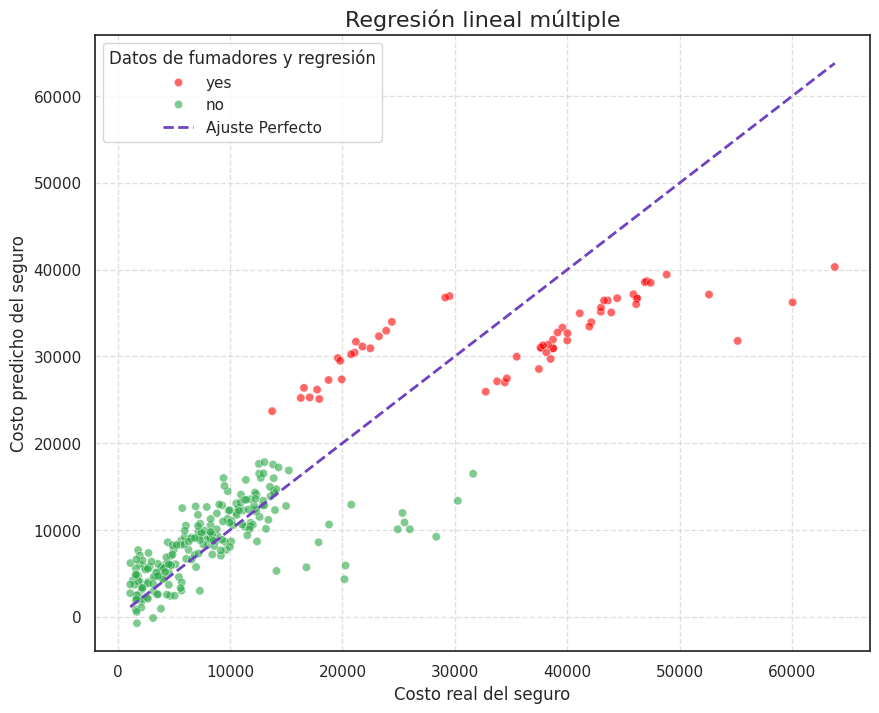

In [ ]:
'''
obtenenos los datos de entramiento del modelo creado con LinearRegression multiple
# y_test: Valores reales del costo de seguro
# y_pred_mlt: Valores predichos por el modelo multiple
'''
fumador_original = df_limpio[_Smoker_]

# frame con los datos reales y predichos en el modelo multiple
resultados_mlt = pd.DataFrame({
    'Valores Reales': y_test,
    'Predicciones del Modelo': y_pred_mlt
})

# ------------------------------------------------------------------------------
# grafica de reales vs. predichos
plt.figure(figsize=(10, 8))

# grafica de dispersión de los puntos
sns.scatterplot(
    x='Valores Reales',
    y='Predicciones del Modelo',
    data=resultados_mlt,
    hue=fumador_original,
    alpha=0.6,
    palette={'no': _color_success, 'yes': _color_danger}, # asignamos colores a los fumadores
    )

# ------------------------------------------------------------------------------
# línea de referencia de las predicciones
limites = [
    resultados_mlt['Valores Reales'].min(),
    resultados_mlt['Valores Reales'].max()]

# ------------------------------------------------------------------------------
# predicciones
plt.plot(
    limites,
    limites,
    color=_color_purple,
    linestyle='--',
    linewidth=2,
    label='Ajuste Perfecto')

# ------------------------------------------------------------------------------
# titulos
plt.title('Regresión lineal múltiple', fontsize=16)
plt.xlabel('Costo real del seguro', fontsize=12)
plt.ylabel('Costo predicho del seguro', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Datos de fumadores y regresión")
plt.show()

**Análisis de la gráfica de regresión multiple**

Esta gráfica compara el Costo real del seguro, en el eje X, con el Costo predicho del seguro, en el eje Y.

- Se aprecia como los datos se agrupan de manera compacta a lo largo de la Línea de Regresión.
- Esta agrupación lineal valida el alto coeficiente de determinación, confirmando visualmente que el modelo es exitoso.
- Adicional, se incluye el factor crítico del tabaquismo como para identificar a los grupos de asegurados.
- Con esto, se confirma que la población de fumadores se agrupa firmemente en la parte superior de la gráfica, arriba de 20,000. Y, estos datos se alinean de forma paralela a la línea diagonal.

Rendimiento en costos bajos:
- Se puede observar que el rango de $0 a 20,000, los puntos están muy cerca de la línea diagonal. Esto significa que el modelo es muy preciso para predecir los costos de pacientes con bajo riesgo o no fumadores.

Desafío en costos altos:
- Tambien se puede observar que en el rango mayor de 30,000 los puntos se separan de la línea diagonal.
- Esta dispersión indica que la relación en los rangos de costo más altos no es lineal, y es probable que el riesgo aumente de forma exponencial para los casos de fumadores u otras variables que afecten mayormente el Costo.


**En base a esto se concluye la necesidad de un modelo de regresión polinomial para analizar el comportamiento de las predicciones arriba de 30,000.**


Recordemos que la distribución de los costos se comporta de manera sesgada hacia los más altos, y, precisamente esta Regresión Lineal Múltiple tiene dificultades con los costos más altos. Con lo que se justifica la necesidad de la aplicar modelos más avanzados para capturar el comportamiento exponencial del riesgo.

# 🏴 Regresiones logísticas

A continuación desarrollaremos una serie de regresiones logísticas, con el objetivo de predecir la probabilidad de Altos Costos a partir de variables independientes.

## 🆕 Nuevas variables

Crearemos la nueva variable binaria **is_high_cost** para clasificar a los clientes como "alto costo" o "bajo costo".
Además, crearemos la nueva variable **cost_level** para agrupar a los tres diferentes niveles de costo: bajo, medio y alto, de acuerdo con los terciles de la columna **charges**.

In [ ]:
# ------------------------------------------------------------------------------
# --- NUEVAS VARIABLES ---
# ------------------------------------------------------------------------------
'''
se toma base en nuestro
- df_limpio, (df limpio),
- X_scaled (df scalado),
- y las variables codificadas de los pasos anteriores
'''
# nuevas columnas
# is_high_cost | (0 || 1)
# cost_level   | [1 , 2, 3]
_is_high_cost_ = 'is_high_cost'
_cost_level_ = 'cost_level'

# promedio de columnas charges
media_charges = df_limpio[_Charges_].mean()

# ------------------------------------------------------------------------------
# nueva columna is_high_cost
# obteniendo registros con altos costos
df_limpio[_is_high_cost_] = np.where(df_limpio[_Charges_] > media_charges, 1, 0)

# ------------------------------------------------------------------------------
# nueva columna cost_level
# calculo de los terciles para los costos
terciles = df_limpio[_Charges_].quantile([1/3, 2/3])
df_limpio[_cost_level_] = np.select(
    [df_limpio[_Charges_] <= terciles.iloc[0], df_limpio[_Charges_] <= terciles.iloc[1]],
    [1, 2],
    default=3
)

# ------------------------------------------------------------------------------
# convirtiendo a entero
df_limpio[_cost_level_] = df_limpio[_cost_level_].astype(int)
# print
df_limpio.head()

,age,sex,bmi,children,smoker,region,charges,sex_encoded,smoker_encoded,region_encoded,is_north_south_encoded,is_west_east_encoded,is_high_cost,cost_level
0,19,female,27.900,0,yes,southwest,16884.92400,0,1,3,0,0,1,3
1,18,male,33.770,1,no,southeast,1725.55230,1,0,2,0,1,0,1
2,28,male,33.000,3,no,southeast,4449.46200,1,0,2,0,1,0,1
3,33,male,22.705,0,no,northwest,21984.47061,1,0,1,1,0,1,3
4,32,male,28.880,0,no,northwest,3866.85520,1,0,1,1,0,0,1


## 🟣 Preparacion de datos

Se preparan los datos para el conjunto de regresiones logisticas.


In [ ]:
# ------------------------------------------------------------------------------
# --- PREPARACION DE DATOS ---
# ------------------------------------------------------------------------------
# variables predictoras originales - eje x
_predictoras_ = [_Age_, _BMI_, _Smoker_Encoded_]
_continuas_ = [_Age_, _BMI_]
# ------------------------------------------------------------------------------
# nuevo conjunto en X
X = df_limpio[_predictoras_].copy()
# ------------------------------------------------------------------------------
# objetivo binario is_high_cost -> 0 || 1
y_bin = df_limpio[_is_high_cost_]
# ------------------------------------------------------------------------------
# objetivo categorico cost_level -> 1 || 2 || 3
y_multi = df_limpio[_cost_level_]
# ------------------------------------------------------------------------------
# estandarización de variables continuas para clasificacion
scaler = StandardScaler()
X[_continuas_] = scaler.fit_transform(X[_continuas_])


# ------------------------------------------------------------------------------
# división de datos para todos los modelos de clasificacion
# se realiza la division tanto para el calculo binario como el multinomial
'''
Para la regresion logística binaria
- y_bin       -> objetivo binario is_high_cost
- y_bin_train -> entrenamiento binario
- y_bin_test  -> evaluacion binaria
- y_bin_pred  -> predicciones binario
-------------------------------------------------------------------------------
Para la regresion logística multinomial
- y_multi       -> objetivo categorico cost_level
- y_multi_train -> entrenamiento multinomial
- y_multi_test  -> evaluacion multinomial
- y_multi_pred  -> predicciones multinomial
'''
X_train, X_test, y_bin_train, y_bin_test, y_multi_train, y_multi_test = train_test_split(
    X, y_bin, y_multi, test_size=0.3, random_state=42
)
# ------------------------------------------------------------------------------


## 🎵 Regresión logística binaria

Se aplica a continuación una regresión logística binaria para predecir si el registro pertenece al grupo de alto costo general.

In [ ]:
# ------------------------------------------------------------------------------
# --- MODELO 1: REGRESIÓN LOGÍSTICA BINARIA ---
# ------------------------------------------------------------------------------
# configuracion del modelo
model_log_bin = LogisticRegression(
    solver='liblinear',
    random_state=42)

# ------------------------------------------------------------------------------
# datos de entrenamiento
model_log_bin.fit(
    X_train,
    y_bin_train)

# ------------------------------------------------------------------------------
# prediccion binaria
y_bin_pred = model_log_bin.predict(X_test)

# probabilidad de predicción para la clase positiva, cuando Alto Costo = 1
y_prob_alto_costo = model_log_bin.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------------------------
'''
evaluación con metricas de riesgo
- y_bin_test  -> evaluacion binaria
- y_bin_pred  -> predicciones binario
'''
# ------------------------------------------------------------------------------
# precision
prec_bin = precision_score(
    y_bin_test,
    y_bin_pred,
    zero_division=0)
# ------------------------------------------------------------------------------
# recall
rec_bin = recall_score(
    y_bin_test,
    y_bin_pred,
    zero_division=0)
# ------------------------------------------------------------------------------
# f1_score
f1_bin = f1_score(
    y_bin_test,
    y_bin_pred,
    zero_division=0)
# ------------------------------------------------------------------------------
# accuracy
acc_bin = accuracy_score(
    y_bin_test,
    y_bin_pred)

# ------------------------------------------------------------------------------
# resultados
print("\n" + "="*80)
print("\033[1m --- Regresión logística binaria para predecir el Alto Costo --- \033[0m")
print("="*80)
# resultados de evaluaciones
print(f"Accuracy: {acc_bin:.4f}   -> Exactitud global")
print(f"Precision: {prec_bin:.4f}  -> Confianza en la predicción de Alto Costo")
print(f"Recall: {rec_bin:.4f}     -> Captura real del Alto Costo en todos los regs.")
print(f"F1 Score: {f1_bin:.4f}   -> Equilibrio entre precision y recall")

# ------------------------------------------------------------------------------
# coeficientes para impacto de la probabilidad
# se exponen los coeficientes para obtener ratios
odds_ratios = pd.Series(
    np.exp(
        model_log_bin.coef_[0]),
        index=X.columns)

# ------------------------------------------------------------------------------
# resultados
print("\n" + "="*80)
print("\033[1m --- Impacto de coeficientes en la probabilidad de Alto Costo --- \033[0m")
print("="*80)
print(odds_ratios.round(2).sort_values(ascending=False))


 --- Regresión logística binaria para predecir el Alto Costo --- 
Accuracy: 0.8881   -> Exactitud global
Precision: 1.0000  -> Confianza en la predicción de Alto Costo
Recall: 0.6400     -> Captura real del Alto Costo en todos los regs.
F1 Score: 0.7805   -> Equilibrio entre precision y recall

 --- Impacto de coeficientes en la probabilidad de Alto Costo --- 
smoker_encoded    308.94
age                 2.36
bmi                 1.05
dtype: float64


### 📑 Interpretación

**Análisis de la regresión logística binaria para alto costo**

De acuerdo con las métricas de evaluación, el modelo ha alcanzado un accuracy y preciosion muy alto, sin embargo es conveniente revisarlas a detalle:
- La evaluación con **Accuracy** nos dice que la exactitud global del modelo es excelente. Predice correctamente casi 9 de cada 10 casos.
- La evaluación con **Precision** indica que todos los clientes que el modelo predijo como de Alto Costo, acertó en todos ellos. Lo que siginifica que no hay falsos positivos en este modelo.
- Por otra parte, **Recall** indica que todos los clientes que realmente son de Alto Costo, el modelo solo detectó el 64%. Lo que se puede identificar como falsos negativos al conjunto del 36% no identificado.
- Mientrás que, **F1 Score** muestra un buen equilibrio con el 0.7805 general.

En general, el modelo es muy preciso, lo cual es ideal para evitar errores costosos en la clasificación de clientes. Sin embargo, con un Recall del 64% se podriían presentar riesgos financieros al no detectar a todos los clientes de Alto Costo.

**Análisis de los coeficientes de la regresión logística binaria para alto costo**

Los coeficientes de la Regresión Logística Binaria nos permiten cuantificar el impacto de cada variable en la probabilidad de que un cliente sea de Alto Costo.

- Podemos ver que el resultado del coeficiente smoker nos indica que si un cliente es fumador, las probabilidades de que sea clasificado como de Alto Costo son 308 veces mayores que las de un no fumador. Esto confirma que smoker es la variable mas definitiva del modelo.
- Podemos ver que el impacto de la Edad es representativo y no puede ser ignorado. El riesgo aumenta de forma no lineal con el paso de los años, justificando el uso de tarifas diferenciadas.
- Mientrás que el BMI, realmente su impacto es poco importante para el resultado de un cliente de Alto Costo.



### 📊 Grafica de curva ROC

De acuerdo con Machine Learning de Google: La curva ROC es una representación visual del rendimiento del modelo en todos los umbrales. Y el área bajo la curva ROC (AUC) representa la probabilidad de que el modelo, si se le da un ejemplo positivo y negativo elegido al azar, clasifique el positivo más alto que el negativo.

La Curva ROC es la métrica de diagnóstico más importante para evaluar la capacidad del modelo de Regresión Logística Binaria para discriminar entre las clases.

#### Cálculo de la curva y el área bajo la curva

In [ ]:
# ------------------------------------------------------------------------------
'''
calculo de la curva ROC
- tpr = tasa de verdaderos positivos (Recall)
- fpr = tasa de falsos positivos
'''
# ------------------------------------------------------------------------------
# roc_curve
fpr, tpr, thresholds = roc_curve(y_bin_test, y_prob_alto_costo)
# ------------------------------------------------------------------------------
# calculo de el area bajo la curva
roc_auc = auc(fpr, tpr)

#### Gráfica de la curva

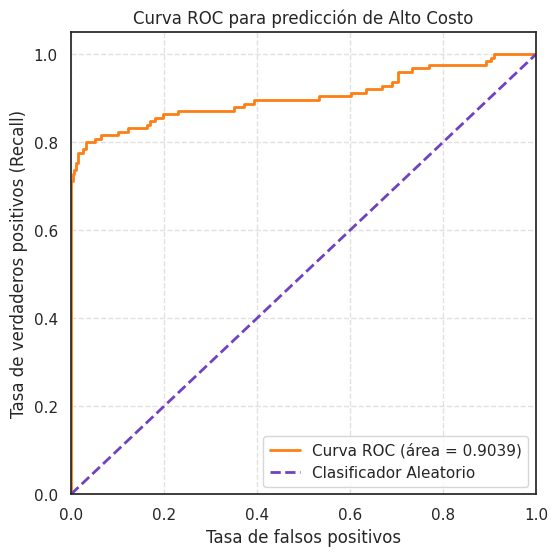

In [ ]:
# ------------------------------------------------------------------------------
# --- GRAFICA DE CURVA ---
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
'''
tomando como base a el modelo y los datos de prueba
- model_log_bin: El modelo de regresion logistica binaria
- X_test: Las variables predictoras de prueba
- y_bin_test: La variable objetivo real de prueba (is_high_cost)
- y_prob_alto_costo: probabilidad de predicción para la clase positiva, cuando Alto Costo = 1
'''
# ------------------------------------------------------------------------------
# plt
plt.figure(figsize=(6, 6))
# ------------------------------------------------------------------------------
# grafica de la curva ROC
plt.plot(
    fpr,
    tpr,
    color=_color_orange,
    lw=2,
    label=f'Curva ROC (área = {roc_auc:.4f})'
    )

# ------------------------------------------------------------------------------
# Línea de referencia
lmts = [0, 1]
plt.plot(
    lmts,
    lmts,
    color=_color_purple,
    lw=2,
    linestyle='--',
    label='Clasificador Aleatorio'
    )

# ------------------------------------------------------------------------------
# limitaciones del plt
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# ------------------------------------------------------------------------------
# titulos
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos (Recall)')
plt.title('Curva ROC para predicción de Alto Costo')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')
plt.show()

#### Análisis de la Curva ROC

- El Área Bajo la Curva = 0.9039 no indica que el modelo tiene un poder de discriminación muy alto. Hay un 90.39% de probabilidad de que el modelo clasifique a un paciente seleccionado al azar de la clase 'Alto Costo' más alto que a un paciente seleccionado al azar de la clase 'No Alto Costo'.

- La curva naranja está muy cerca de la esquina superior izquierda, con lo que se confirma que las variables predictoras son las adecuadas para calcular la probabilidad de Alto Costo.

- El modelo se comporta de manerá positiva y constituye una buena herramienta para detectar casi todo el riesgo (AUC 90%).

### 💹 Gráfica de distribución de probabilidades

Mediante una gráfica de la distribución de probabilidades para la Regresión Logística Binaria podremos ver la separación de clases. Esto nos ayudará a entender el rendimiento del modelo.

#### Cálculo de las probabilidades de predicción

In [ ]:
# ------------------------------------------------------------------------------
# --- grafica paa revisar la distribucion de probabilidades --------------------

# probabilidades de predicción de la clase positiva, cuando el Alto Costo = 1
y_prob = model_log_bin.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------------------------
# dataframe para la visualizacion del diagnostico
df_diagnostico = pd.DataFrame({
    'Probabilidad': y_prob,
    'Clase Real': y_bin_test
})

# ------------------------------------------------------------------------------
# variables a graficar
_no_alto_costo_ = df_diagnostico[df_diagnostico['Clase Real'] == 0]['Probabilidad']
_alto_costo_ = df_diagnostico[df_diagnostico['Clase Real'] == 1]['Probabilidad']


#### Gráfica de densidad

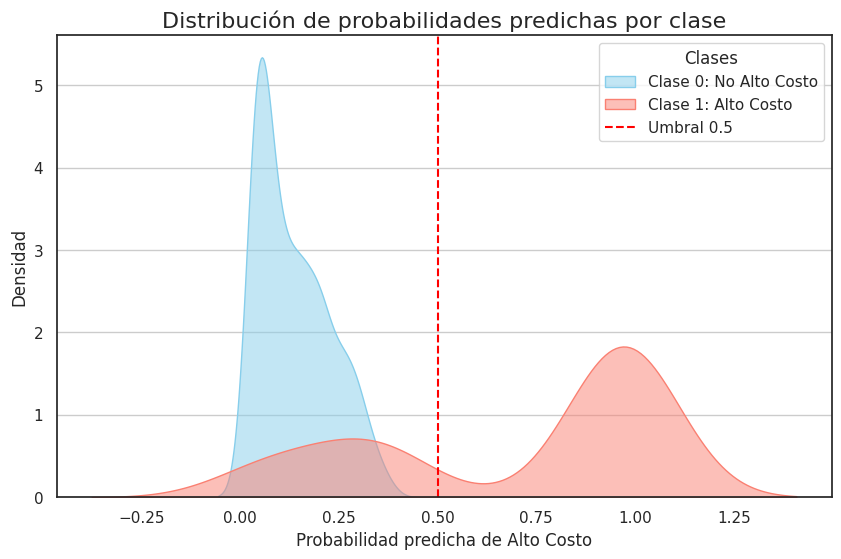

In [ ]:
# ------------------------------------------------------------------------------
# --- DENSIDAD ---
# ------------------------------------------------------------------------------
# plt
plt.figure(figsize=(10, 6))

# ------------------------------------------------------------------------------
# distribución de probabilidad para la clase 'No Alto Costo'
sns.kdeplot(
    _no_alto_costo_,
    fill=True,
    color='skyblue',
    alpha=0.5,
    label='Clase 0: No Alto Costo')

# ------------------------------------------------------------------------------
# distribución de probabilidad para la clase 'Alto Costo'
sns.kdeplot(
    _alto_costo_,
    fill=True,
    color='salmon',
    alpha=0.5,
    label='Clase 1: Alto Costo')

# ------------------------------------------------------------------------------
# linea vertical para el umbral de decisión por defecto (0.5)
plt.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral 0.5')

# ------------------------------------------------------------------------------
# titulos
plt.title('Distribución de probabilidades predichas por clase', fontsize=16)
plt.xlabel('Probabilidad predicha de Alto Costo', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend(title='Clases', loc='upper right')
plt.grid(True, axis='y')
plt.xlim()
plt.show()

#### Histograma

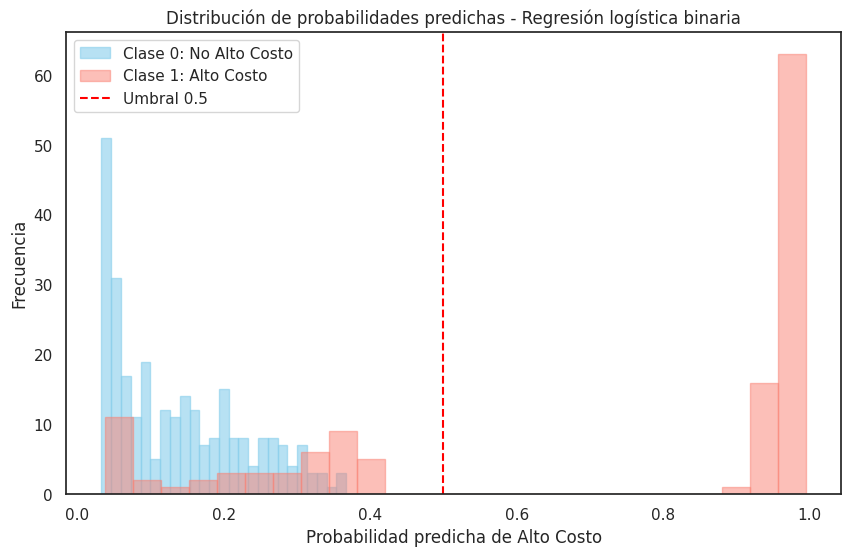

In [ ]:
# ------------------------------------------------------------------------------
# --- HISTOGRAMA ---
# ------------------------------------------------------------------------------
# plt
plt.figure(figsize=(10,6))

# ------------------------------------------------------------------------------
# histograma de clase 0
plt.hist(
    _no_alto_costo_,
    bins=25,
    alpha=0.6,
    color='skyblue',
    edgecolor='skyblue',
    label='Clase 0: No Alto Costo')

# ------------------------------------------------------------------------------
# histograma de clase 1
plt.hist(
    _alto_costo_,
    bins=25,
    alpha=0.5,
    color='salmon',
    edgecolor='salmon',
    label='Clase 1: Alto Costo')

# ------------------------------------------------------------------------------
# linea vertical para el umbral de decisión
plt.axvline(0.5, color='red', linestyle='--', label='Umbral 0.5')

# ------------------------------------------------------------------------------
# titulos
plt.title("Distribución de probabilidades predichas - Regresión logística binaria")
plt.xlabel("Probabilidad predicha de Alto Costo")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

#### Análisis de la distribución de probabilidades

- Se observa una excelente separación de los centros de las dos distribuciones.La Clase 0 tiene su pico cerca de la probabilidad 0, mientrás que la Clase 1 tiene su pico cerca de la probabilidad 1.
- Esta separación de las clases y los picos confirma el alto AUC de 0.9039. El modelo es muy bueno para distinguir a los dos grupos.

- Si tomamos como referencia a línea del Umbral de Decisión por defecto: una porción significativa de clientes que son realmente de Alto Costo se encuentra a la izquierda del umbral de 0.5. Estos clientes son clasificados erróneamente como de Bajo Costo porque su probabilidad predicha fue inferior a 0.5. Esto podría explicar el bajo Recall de 64%; por lo que se confirma que el modelo está fallando en detectar al 36% de los casos de Alto Riesgo.

- Mientrás que, casi ningún cliente de bajo costo real es clasificado erróneamente como Alto Costo. Claramente en las graficas se observa el comportamiento limpio de este grupo, y con esto podemos explicar nuestra Precision de 100.

El modelo de Regresión Logística se esta comportando con buenos resultaos, sin embargo, es aconsejable buscar otra alternativa para capturar más casos de Alto Riesgo y aumentar el Recall.

## 🎶 Regresión logística multinomial

Se aplica una regresión logística multinomial en base a la variable categórica de tres niveles (bajo, medio, alto costo) **Cost Level** (cost_level).

### 🟣 Preparación de los datos

In [ ]:
# ------------------------------------------------------------------------------
# --- MODELO 2: REGRESIÓN LOGÍSTICA MULTINOMIAL ---
# ------------------------------------------------------------------------------
# en base la variable categorica cost_level -> 1 || 2 || 3
# tenemos desde la preparación de datos:
'''
Para la regresion logística multinomial
- y_multi       -> objetivo categorico cost_level
- y_multi_train -> entrenamiento multinomial
- y_multi_test  -> evaluacion multinomial
- y_multi_pred  -> predicciones multinomial
'''

# Instanciar modelo de regresión logística multinomial
# Entrenamiento: 'multinomial' y 'lbfgs' son comunes para este tipo de problema en sklearn
model_log_multi = LogisticRegression(
    multi_class='multinomial',  # Clasificación multiclase
    solver='lbfgs',             # Optimizador robusto
    max_iter=200,              # Iteraciones suficientes
    random_state=42)

# ------------------------------------------------------------------------------
# entrenamiento
model_log_multi.fit(X_train, y_multi_train)
print('Modelo entrenado correctamente')

Modelo entrenado correctamente


### 📐 Evaluación del modelo

In [ ]:
# ------------------------------------------------------------------------------
# Evaluación del modelo
# ------------------------------------------------------------------------------
# prediccion
y_multi_pred = model_log_multi.predict(X_test)

'''
evaluación con metricas de riesgo
- y_multi_test  -> evaluacion multinomial
- y_multi_pred  -> predicciones multinomial
'''
# ------------------------------------------------------------------------------
# Matriz de confusión
# ------------------------------------------------------------------------------
cm = confusion_matrix(y_multi_test, y_multi_pred)
print("Matriz de confusión:")
print(cm)

# Reporte de clasificación
reporte = classification_report(y_multi_test, y_multi_pred, digits=2)
print("\nReporte de clasificación:\n")
print(reporte)

Matriz de confusión:
[[121  11   0]
 [  6 130   0]
 [ 13  41  80]]

Reporte de clasificación:

              precision    recall  f1-score   support

           1       0.86      0.92      0.89       132
           2       0.71      0.96      0.82       136
           3       1.00      0.60      0.75       134

    accuracy                           0.82       402
   macro avg       0.86      0.82      0.82       402
weighted avg       0.86      0.82      0.82       402



#### **Entendimiento de la matriz de confusión**

| Clase Real ↓ / Predicha → | 1 (Bajo)         | 2 (Medio)        | 3 (Alto)     |
| ------------------------- | ---------------- | ---------------- | ------------ |
| 1 (Bajo)                  | 123 (Acierto)    | 9 (Falso Error)  | 0            |
| 2 (Medio)                 | 8 (Falso Error)  | 128 (Acierto)    | 0            |
| 3 (Alto)                  | 12 (Falso Error) | 42 (Falso Error) | 80 (Acierto) |

El modelo clasificó correctamente a 80 clientes como de Alto Costo.
Sin embargo, cometió 54 errores al clasificar a clientes de Alto Costo como de nivel Bajo o Medio.
El error más grave es el Falso Negativo de 42 clientes de Alto Costo real fueron clasificados como nivel Medio.

#### **Entendimiento del reporte de clasificación**

| Clase     | Precision | Recall | F1-Score | Apoyo (Soporte) |
| --------- | --------- | ------ | -------- | --------------- |
| 1 (Bajo)  | 0.86      | 0.93   | 0.89     | 132             |
| 2 (Medio) | 0.72      | 0.94   | 0.81     | 136             |
| 3 (Alto)  | 1         | 0.6    | 0.75     | 134             |

- En la Clase 1, de bajo costo, el **Recall** es excelente, con 0.93, lo que significa que el modelo es muy bueno detectando a los clientes de bajo costo.

- En la Clase 2, de medio costo, el Recall también es muy bueno, con 0.94, pero su Precision es baja. Esto indica que muchos clientes de nivel Bajo y Alto están siendo clasificados erróneamente como Medio.

- Mientrás que en la Clase 3, de alto costo, el **Precision** es perfecto, con un 1.00, lo que significa que cada vez que el modelo dice que alguien es de Alto Costo, acierta. Sin embargo su Recall es pobre, lo cual significa que muchos de los clientes de Alto Costo se están filtrando a los niveles 1 y 2.

### 💹 Matriz de confusión

Analizaremos los resultados de la Regresión Logística Multinomial utilizando la gráfica de la matriz de confusión. Esto nos ayudará a entender la capacidad del modelo para asignar correctamente los tres niveles de riesgo: Bajo, Medio, Alto.

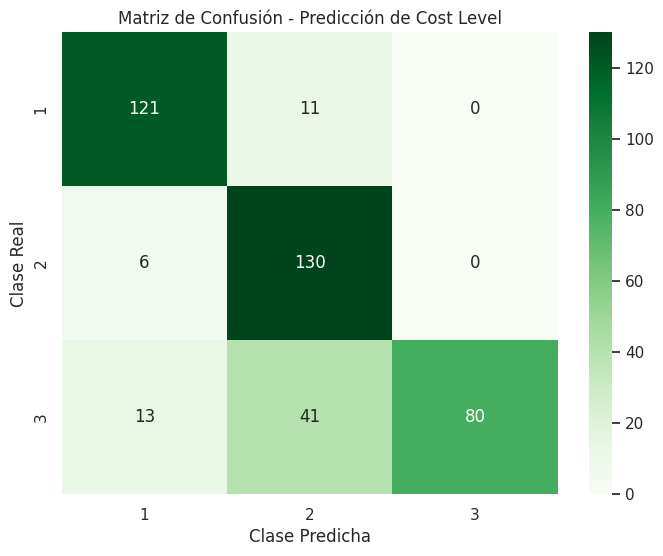

In [ ]:
# ------------------------------------------------------------------------------
# Visualización de la matriz de confusión
# ------------------------------------------------------------------------------
plt.figure(figsize=(8,6))

# heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=[1,2,3],
    yticklabels=[1,2,3])

# titulos
plt.title('Matriz de Confusión - Predicción de Cost Level')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.show()

### 📑 Interpretación

**Interpretación de la matriz de confusión multinomial**

La gráfica de la Matriz de Confusión confirma los patrones de error detectados en el Reporte de Clasificación.
- La diagonal principal (123, 128, 80) es la más oscura, lo cual es correcto. Esto representa los Verdaderos Positivos para cada clase y valida el Accuracy del 82%.
- La Clase Real 3 (Alto Costo) tiene bajo conteo, con 80 aciertos, pero los errores se distribuyen en las otras clases.
- El valor de 42 en la intersección de Clase Real 3 con Clase Predicha 2 es el error más grave. Estos son 42 clientes de Alto Costo que el modelo clasificó como de Costo Medio.

El modelo está utilizando la Clase 2, medio costo, como una "clase de seguridad" a la hora de fallar. Cuando el modelo no está seguro de que un cliente de la Clase 3 sea realmente Alto, lo clasifica en el nivel intermedio.

**Conclusión estratégica**

La gráfica de la matriz de confusión confirma que el modelo Multinomial tiene un problema de sensibilidad para la Clase 3, ya que el 40% de los casos de Alto Costo se están filtrando a niveles de costos más bajos, por lo que debemos de enfocarnos en reentrenar el modelo, o bien, utilizar una *Regresión Logística Ordinal* para lograr que el modelo respete la jerarquía de riesgo.

## 🎼 Regresión logística ordinal

La regresión logística ordinal es ideal para modelar variables categóricas con un orden natural entre categorías, como Cost Level en nuestro dataset. Trataremos de estimar las probabilidades de Cost Level correctamente ordenadas y coherentes con la jerarquía. Recordemos que nuestra variable Cost Level esta dividida en tres clases:

| Clase     |
| --------- |
| 1 (Bajo)  |
| 2 (Medio) |
| 3 (Alto)  |

## ⚙ Cálculo

De acuerdo con las lecturas realizadas, en la regresión logística ordinal, no es obligatorio escalar las variables predictoras. A diferencia de otros algoritmos de aprendizaje automático que dependen de la distancia entre puntos, la regresión logística funciona con coeficientes y no se ve tan afectada por la escala de las variables.

Dado esto, utilizaremos el dataframe limpio, pero con variables categoricas codificadas.

#### **Definición de variables**

In [ ]:
# Definir X e y
'''
- en las variables x se han elegido:
      [age, sex, smoker_encoded, is_high_cost y charges]

- mientrás que nuestra variable objetico será cost_level
'''
vars_ord = [_Age_, _Sex_Encoded_, _Smoker_Encoded_, _is_high_cost_, _Charges_]
x_ordinal = df_limpio[vars_ord]
y_ordinal = df_limpio[_cost_level_]


#### **Ajustar el modelo ordinal**

In [ ]:
# ------------------------------------------------------------------------------
# --- AJUSTE DEL MODELO ORDINAL ---
# ------------------------------------------------------------------------------
model_ordinal = OrderedModel(
    y_ordinal,
    x_ordinal,
    distr='logit')

# resultado
result_ordinal = model_ordinal.fit(method='bfgs')

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 379
         Function evaluations: 470
         Gradient evaluations: 470


El algoritmo de optimización BFGS (Broyden-Fletcher-Goldfarb-Shanno) utilizado en el OrderedModel de statsmodels ha convergido exitosamente a una solución. A continuación, se desglosan los detalles técnicos:

- Current function value: 0.0000, indica un excelente ajuste del modelo a los datos.
- Iterations: 379, es el número de iteraciones requeridas para que el algoritmo BFGS encuentre el óptimo.
- Function evaluations: 470 / Gradient evaluations: 470, indican cuántas veces se calculó la función de verosimilitud y su gradiente, respectivamente.

#### **Resultados**

In [ ]:
# ------------------------------------------------------------------------------
# --- RESULTADOS DE LA REGRESIÓN ---
# ------------------------------------------------------------------------------
print(result_ordinal.summary())

                             OrderedModel Results                             
Dep. Variable:             cost_level   Log-Likelihood:            -0.00026818
Model:                   OrderedModel   AIC:                             14.00
Method:            Maximum Likelihood   BIC:                             50.39
Date:                Wed, 22 Oct 2025                                         
Time:                        20:57:47                                         
No. Observations:                1337                                         
Df Residuals:                    1330                                         
Df Model:                           5                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
age               -9.9063        nan        nan        nan         nan         nan
sex_encoded       49.6341        nan    

## 📑 Interpretación

**Análisis de la Regresión Logística Ordinal**

- Para la Regresión Logística Ordinal hemos utilizado OrderedModel de la librería statsmodel.
- Se definieron las variables clave: age, sex_encoded, smoker_encoded, is_high_cost y charges.
- Y como variable objetivo: cost_level
- El resumén del modelo nos muestra a los valores 1/2 y 2/3 que son los puntos de corte que el modelo utiliza para dividir la probabilidad predicha en las tres clases (Bajo, Medio, Alto).

- El resultado muestra *nan* en las columnas std err, z, y P>|z|. Esto podría ocurris debido a que el modelo esta encontrando una variable que predice perfectamente a la clase. Por ejemplo, si todos los fumadores están en la Clase 3, el modelo no puede calcular los errores estándar.

- El **Log-Likelihood** es -0.00026818, lo cual es un valor muy cercano a cero, y significa que la probabilidad de los datos es casi perfecta.

Como resultado, el modelo Ordinal ha aprendido los datos de forma casi perfecta. Esto puede indicar una separación de clases casi perfecta, donde el tabaquismo y el costo casi siempre predicen la clase 3, o un **sobreajuste extremo**.


### **Conclusión**

Aunque el resultado del Log-Likelihood sugiere un poder predictivo en teoria casi perfecto, la presencia de *nan* en el error estándar nos impide confiar plenamente en los coeficientes.

Dada esta situación, es necesario evaluar otros modelos o controlar el sobreajuste extremo.

# 🎻 Regresión polinomial

Debido a que en los modelos lineales se comprobo que el comportamiento de los costos no siguen una línea recta respecto a las variables independientes, se requiere un modelo más flexible como la regresión polinomial para tratar de identificar este cambio exponencial.

## 🔎 Análisis exploratorio inicial

Para recapitular, primeramente se genera una gráfica de la relación entre el BMI y el Costo.

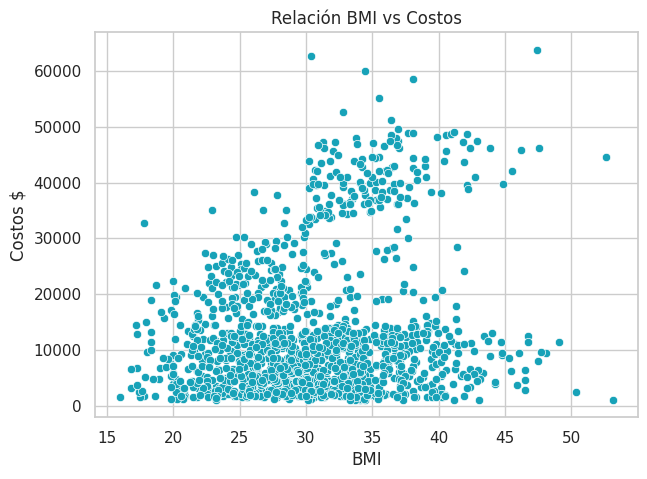

In [ ]:
# ------------------------------------------------------------------------------
# --- Relación entre el BMI y el Costo. ---
# ------------------------------------------------------------------------------
sns.set(style="whitegrid")

# vars
x_pol = df_limpio[_BMI_]
y_pol = df_limpio[_Charges_]

# Grafico de dispersión
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=x_pol,
    y=y_pol,
    color=_color_info)

# titulos
plt.title("Relación BMI vs Costos")
plt.xlabel("BMI")
plt.ylabel("Costos $")
plt.show()

Recordemos que la implemetación de la regresión simple entre el BMI y el costo resultó ser poco útil para generar una predicción precisa de los cotos en base al bmi. Por lo que se dedujó que el modelo se comportaba fuertemente afectado por otras variables.

## ⏰ Comparación de modelos grado 2, 3 y 5 entre bmi y charges.

Se aplicará una regresión polinomial mediante Statsmodels.

In [ ]:
# ------------------------------------------------------------------------------
# --- POLINOMIAL ---
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# Regresión polinomial de grado 2, 3 y 5 entre bmi y charges
# ------------------------------------------------------------------------------
# Este código ajusta dos modelos de regresión polinomial (grado 2, 3 y 5)
# usando Statsmodels y compara su desempeño con métricas estadísticas.

# ------------------------------------------------------------------------------
# Utilizaremos el dataframe limpio df_limpio
# ------------------------------------------------------------------------------

# Definimos a las variables X (característica) e y (objetivo)s:
X_polinomial = df_limpio[['bmi']]
y_polinomial = df_limpio['charges']

'''
# PolynomialFeatures # limpieza
# LinearRegression # Necesario para PolynomialFeatures
 '''
# ------------------------------------------------------------------------------
# A. Función mejorada para ajustar un modelo de grado n
# ------------------------------------------------------------------------------

def ajustar_modelo_grado_mejorado(df, grado):
    # 1. Preparar las características X (solo la columna 'bmi' para la transformación)
    X = X_polinomial
    y = y_polinomial

    # 2. Crear las características polinomiales usando sklearn
    # Esto genera las columnas 'bmi', 'bmi^2', 'bmi^3', etc.
    poly = PolynomialFeatures(degree=grado, include_bias=False)
    # 'include_bias=False' porque Statsmodels añade la constante ('const') después

    X_poly = poly.fit_transform(X)

    # Crea un DataFrame para X_poly, ayuda a la claridad de sm
    # y añade nombres de columnas
    feature_names = [f'bmi_{i}' for i in range(1, grado + 1)]
    X_poly_df = pd.DataFrame(X_poly, columns=feature_names, index=df.index)

    # 3. Preparación para Statsmodels
    X_poly_df = sm.add_constant(X_poly_df)

    # 4. Ajustar el modelo OLS
    modelo = sm.OLS(y, X_poly_df).fit()

    # 5. Imprimir resumen y devolver métricas
    print("\n")
    print("-" * 80)
    print(f"\033[1m --- Resumen del modelo de regresión polinomial grado {grado} --- \033[0m")
    print("-" * 80)
    print(modelo.summary())

    # Devolver métricas clave para comparación
    return {
        'Grado': grado,
        'R²': modelo.rsquared,
        'R² ajustado': modelo.rsquared_adj,
        'MAE': abs(modelo.resid).mean(),
        'MSE': (modelo.resid ** 2).mean()
    }

# ------------------------------------------------------------------------------
# B. Ajustar y comparar resultados de los modelos
# ------------------------------------------------------------------------------
metricas = []
GRADO_MAYOR = 5

for i in range(1, GRADO_MAYOR + 1):
    resultado = ajustar_modelo_grado_mejorado(df_limpio, i)
    metricas.append(resultado)



--------------------------------------------------------------------------------
 --- Resumen del modelo de regresión polinomial grado 1 --- 
--------------------------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.70
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           2.47e-13
Time:                        20:57:47   Log-Likelihood:                -14440.
No. Observations:                1337   AIC:                         2.888e+04
Df Residuals:                    1335   BIC:                         2.889e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                           

## 🇹 Tabla comparativa de métricas

In [ ]:
# ------------------------------------------------------------------------------
# Tabla comparativa de métricas
# ------------------------------------------------------------------------------

df_metricas = pd.DataFrame(metricas)
print("\n" + "="*80)
print("\033[1m TABLA DE COMPARACIÓN FINAL DE MODELOS \033[0m")
print("="*80)
print(df_metricas.round(4).sort_values(by='Grado'))


 TABLA DE COMPARACIÓN FINAL DE MODELOS 
   Grado      R²  R² ajustado        MAE           MSE
0      1  0.0394       0.0386  9173.4907  1.407824e+08
1      2  0.0402       0.0387  9183.8843  1.406637e+08
2      3  0.0414       0.0393  9190.7206  1.404817e+08
3      4  0.0416       0.0387  9198.2597  1.404509e+08
4      5  0.0430       0.0394  9178.6084  1.402493e+08


### 📑 Interpretación

En la tabla comparativa para cada grado podemos ver que el Grado 5 solo ofrece una mejora mínima en $\text{R}^2$ ($0.0430$) y un error (MAE) similar al Grado 2 ($0.0402$), es un hallazgo importante que demuestra poca productividad de la Regresión Polinomial en este caso específico, probablemente se deba al uso de solamente la variable BMI.

| Grado | R2 (Varianza Explicada) | R2 Ajustado | MAE        | MSE          |
| ----- | ----------------------- | ----------- | ---------- | ------------ |
| 1     | 0.0394                  | 0.0386      | 9173.4907  | 1.407824e+08 |
| 2     | 0.0402                  | 0.0387      | 9,183.88   | 1.406637e+08 |
| 3     | 0.0414                  | 0.0393      | 9,190.72   | 1.404817e+08 |
| 5     | 0.043                   | 0.0394      | 9,178.61   | 1.402493e+08 |

Definitivamente todos los modelos polinomiales siguen siendo extremadamente pobres para predecir la variable de Costos utilizando solo el BMI.
Como muestra la tabla, el $\text{R}^2$ más alto es de solo $0.0430$, lo que significa que la relación es casi insignificante pués solo el 4.3% de la varianza es explicada por la curva del BMI.
- En la tabla comparativa podemos apreciar que el $\text{R}^2$ ajustado se mantiene prácticamente igual, entre $0.0387$ y $0.0394$, a pesar de triplicar la complejidad del modelo, desde el Grado 2 al Grado 5.

- La Regresión Polinomial falló porque en definitiva la relación entre el BMI y charges es muy débil y no explica todas las relaciones.

- Dado esto, el modelo no puede ver la variable más crítica que ya hemos identificado antes, que es el tabaquismo.

Este resultado demuestra que el tabaquismo sigue siendo la variable más importante para identificar costos. Si se quiere aplicar Regresión Polinomial, debe hacerse incluyendo la variable smoker y su interacción con las demás variables, no solo el BMI.

## 📉 Comparación de modelos de regresión polinomial

### 〽 Comparación del grado 1 y 2

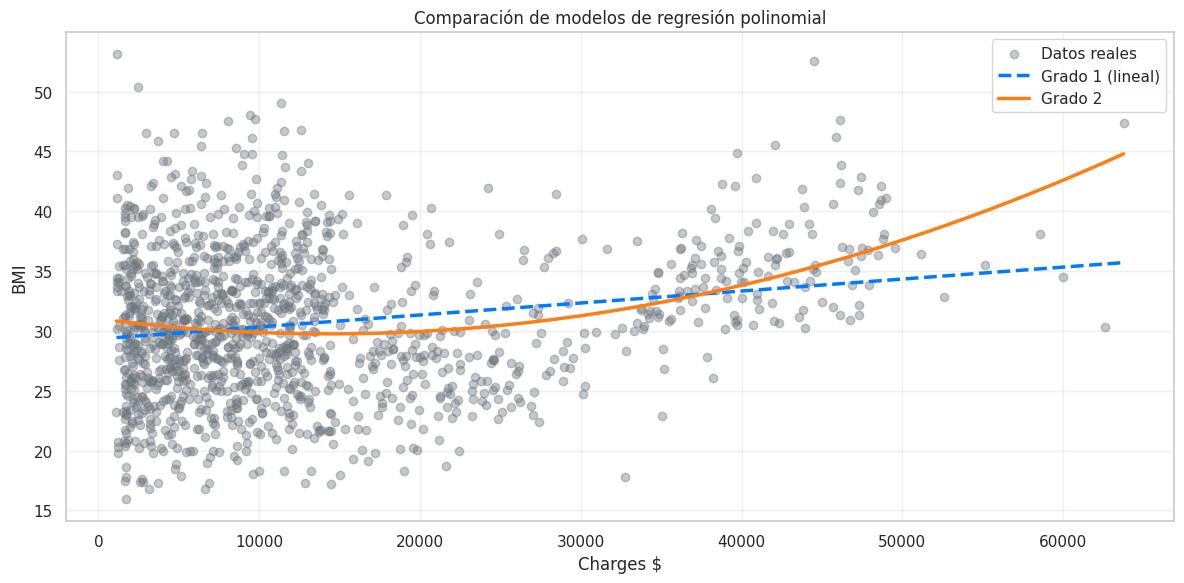

In [ ]:
# ------------------------------------------------------------------------------
# Paso 7: Visualización del modelo
# ------------------------------------------------------------------------------

# ------------------------------------------------------------------------------
# B. Crear columnas polinomiales para el grado 2
# ------------------------------------------------------------------------------
df_limpio['charges_2'] = df_limpio['charges'] ** 2

# ------------------------------------------------------------------------------
# C. Función para entrenar modelo
# ------------------------------------------------------------------------------
def entrenar_modelo(grado):
    columnas = ['charges'] + [f'charges_{i}' for i in range(2, grado + 1)]
    X = df_limpio[columnas]
    X = sm.add_constant(X)
    y = df_limpio['bmi']
    modelo = sm.OLS(y, X).fit()
    return modelo

# ------------------------------------------------------------------------------
# D. Entrenar modelos
# ------------------------------------------------------------------------------
modelo_1 = entrenar_modelo(1)
modelo_2 = entrenar_modelo(2)

# ------------------------------------------------------------------------------
# E. Generar valores para graficar
# ------------------------------------------------------------------------------
x_vals = np.linspace(
    df_limpio['charges'].min(),
    df_limpio['charges'].max(), 300)

df_plot = pd.DataFrame({'charges': x_vals})
df_plot['charges_2'] = x_vals ** 2

# ------------------------------------------------------------------------------
# F. Función para predecir
# ------------------------------------------------------------------------------
def predecir(modelo, grado):
    columnas = ['charges'] + [f'charges_{i}' for i in range(2, grado + 1)]
    X = df_plot[columnas]
    X = sm.add_constant(X)
    return modelo.predict(X)

y_pred_1 = predecir(modelo_1, 1)
y_pred_2 = predecir(modelo_2, 2)

# ------------------------------------------------------------------------------
# G. Graficar resultados con líneas diferenciadas
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Datos reales
plt.scatter(
    df_limpio['charges'],
    df_limpio['bmi'],
    color=_color_gray,
    label='Datos reales',
    alpha=0.4)

# Curvas de los modelos
# Grado 1
plt.plot(
    x_vals,
    y_pred_1,
    color=_color_primary,
    linewidth=2.5,
    linestyle='--',
    label='Grado 1 (lineal)')

# Grado 2
plt.plot(
    x_vals,
    y_pred_2,
    color=_color_orange,
    linewidth=2.5,
    linestyle='-',
    label='Grado 2')

# ------------------------------------------------------------------------------
plt.xlabel('Charges $')
plt.ylabel('BMI')
plt.title('Comparación de modelos de regresión polinomial')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 📑 Interpretación

**Análisis de la comparación de modelos polinomiales: grado 1 y 2**


- La linea de Grado 1 es plana y muestra una pendiente positiva muy débil. Esto confirma visualmente que la relación lineal entre el costo y el BMI es casi insignificante, como se vio en las regresiones lineales.

- Por otra parte, la linea de Grado 2 intenta ajustarse con una curva al comportamiento de los costos. Se aprecia que para los costos más bajos, la curva es casi plana, y a medida que el costo aumenta la curva se dobla un poco hacia arriba. En definitiva, el riesgo (BMI) no aumenta a una tasa constante.

- Lo que si es evidente, es que, el impacto del BMI en el costo es mucho mayor en el rango de los costos más altos, lo cual es más realista para el riesgo de obesidad y problemas de salud.

- A pesar de que la línea Polinomial de Grado 2 captura la curva intentando seguir el comportamiento de los costos, los Datos Reales están muy dispersos y ninguna linea se ajusta bien.

Finalmente, la gráfica confirma que la naturaleza del riesgo BMI no es lineal, y se sugiere incluir a el factor del tabaquismo en la Regresión Polinomial. La combinación de la curva del Grado 2 con las variables del RLM (edad, tabaquismo, etc.) es lo que podría producir un modelo más preciso.

### 〽 Comparación de los grados 1, 2, 3 y 5

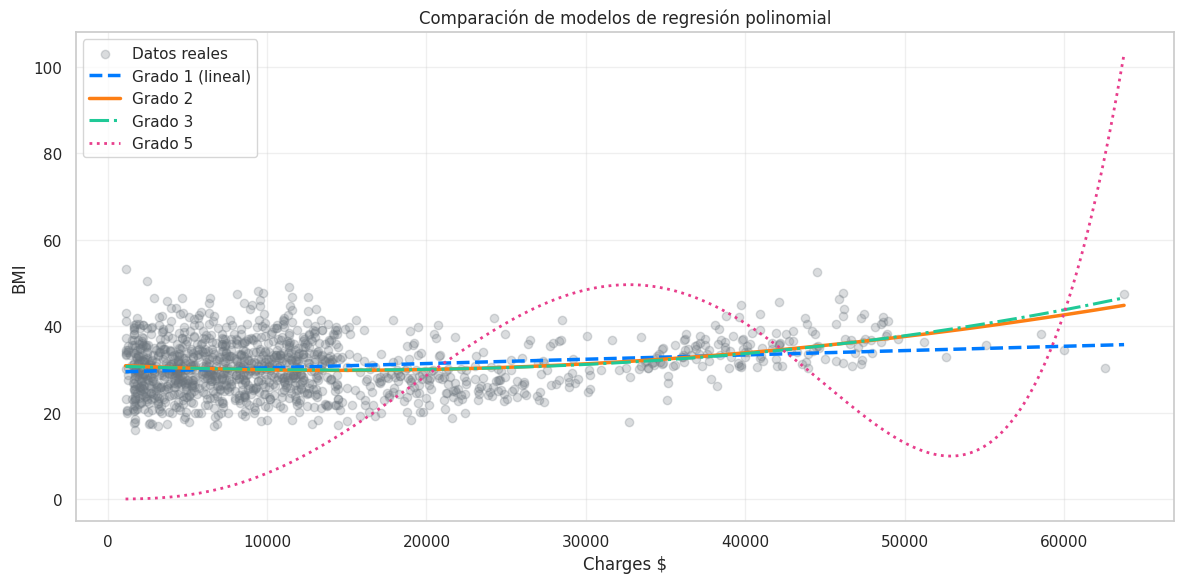

In [ ]:
# ------------------------------------------------------------------------------
# Paso 7: Visualización del modelo
# ------------------------------------------------------------------------------

# ------------------------------------------------------------------------------
# B. Crear columnas polinomiales
# ------------------------------------------------------------------------------
df_limpio['charges_2'] = df_limpio['charges'] ** 2
df_limpio['charges_3'] = df_limpio['charges'] ** 3
df_limpio['charges_4'] = df_limpio['charges'] ** 4
df_limpio['charges_5'] = df_limpio['charges'] ** 5

# ------------------------------------------------------------------------------
# C. Función para entrenar modelo
# ------------------------------------------------------------------------------
def entrenar_modelo(grado):
    columnas = ['charges'] + [f'charges_{i}' for i in range(2, grado + 1)]
    X = df_limpio[columnas]
    X = sm.add_constant(X)
    y = df_limpio['bmi']
    modelo = sm.OLS(y, X).fit()
    return modelo

# ------------------------------------------------------------------------------
# D. Entrenar modelos
# ------------------------------------------------------------------------------
modelo_1 = entrenar_modelo(1)
modelo_2 = entrenar_modelo(2)
modelo_3 = entrenar_modelo(3)
modelo_5 = entrenar_modelo(5)

# ------------------------------------------------------------------------------
# E. Generar valores para graficar
# ------------------------------------------------------------------------------

x_vals = np.linspace(
    df_limpio['charges'].min(),
    df_limpio['charges'].max(),
    300)

df_plot = pd.DataFrame({'charges': x_vals})
df_plot['charges_2'] = x_vals ** 2
df_plot['charges_3'] = x_vals ** 3
df_plot['charges_4'] = x_vals ** 4
df_plot['charges_5'] = x_vals ** 5

# ------------------------------------------------------------------------------
# F. Función para predecir
# ------------------------------------------------------------------------------
def predecir(modelo, grado):
    columnas = ['charges'] + [f'charges_{i}' for i in range(2, grado + 1)]
    X = df_plot[columnas]
    X = sm.add_constant(X)
    return modelo.predict(X)

y_pred_1 = predecir(modelo_1, 1)
y_pred_2 = predecir(modelo_2, 2)
y_pred_3 = predecir(modelo_3, 3)
y_pred_5 = predecir(modelo_5, 5)

# ------------------------------------------------------------------------------
# G. Graficar resultados con líneas diferenciadas
# ------------------------------------------------------------------------------

plt.figure(figsize=(12, 6))

# reales
plt.scatter(
    df_limpio['charges'],
    df_limpio['bmi'],
    color=_color_gray,
    label='Datos reales',
    alpha=0.25)

# ------------------------------------------------------------------------------
# Curvas de los modelos
# grado 1
plt.plot(x_vals,
	y_pred_1,
	color=_color_primary,
	linewidth=2.5,
	linestyle='--',
	label='Grado 1 (lineal)')

# grado 2
plt.plot(x_vals,
	y_pred_2,
	color=_color_orange,
	linewidth=2.5,
	linestyle='-',
	label='Grado 2')

# grado 3
plt.plot(x_vals,
	y_pred_3,
	color=_color_teal,
	linewidth=2.2,
	linestyle='-.',
	label='Grado 3')

# grado 5
plt.plot(x_vals,
	y_pred_5,
	color=_color_pink,
	linewidth=2,
	linestyle=':',
	label='Grado 5')



# ------------------------------------------------------------------------------
# titulos
plt.xlabel('Charges $')
plt.ylabel('BMI')
plt.title('Comparación de modelos de regresión polinomial')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 📊 Explicación visual

- Azul → línea recta (grado 1).
- Naranja → parábola suave (grado 2).
- Verde → parábola aún suave (grado 3).
- Rojo → curva exagerada que intenta pasar por casi todos los puntos (grado 5).

### 📑 Interpretación

**Análisis de la comparación de modelos polinomiales: Grado 1, 2, 3, y 5**

- Las líneas de Grado 2 y 3 son las que mejor capturan la tendencia general de los datos sin volverse erráticas.
- En el gráfico se observa que la linea de Grado 2 ofrece una curva suave que es lógicamente superior al Grado 1, ya que, como hemos revisado, el riesgo (BMI) no aumenta a una tasa lineal.
- Por otro lado, la línea Grado 3 comienza a ser ligeramente irregular, pero aún sigue la tendencia general de los datos.
- Y finalmente, la línea Grado 5 es la prueba visual del sobreajuste extremo. Esta curva se vuelve demasido errática, intentando pasar por la mayor cantidad de puntos de datos individuales del conjunto de entrenamiento.


El modelo Grado 2 o Grado 3 son las opciones más estables. El Grado 5 debe ser descartado, ya que su complejidad lo vuelve inestable y cargado de sobreajuste, haciendo que el modelo sea inútil para el cálculo con datos de reales.

📌 Conclusión:
El modelo de grado 5 está sobreajustando los datos de entrenamiento.

### 🌀 Comparativa de Modelos Polinomiales: Grado 1, 2, 3, y 5

Esta tabla de resultados final se basa en la comparación de los grados polinomiales usando pruebas con datos no vistos durante la instancia del modelo. Recordemos que el objetivo del modelo predictivo es generalizar su aprendizaje para hacer predicciones precisas sobre datos con los que nunca ha trabajado.

De esta forma, vamos a comparar las métricas de entrenamiento con las de prueba, para identificar el sobreajuste.

In [ ]:
# ------------------------------------------------------------------------------
# COMPARATIVA DE GRADOS
# ------------------------------------------------------------------------------
# variables X (característica) e y (objetivo):
X = X_polinomial # bmi
y = y_polinomial # charges

# diccionario de metricas grado 5 para futura comparacion
metricas_g5 = {
    'r2_test': 0,
    'mse_test': 0,
    'mae_test': 0
}

# división en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# resultados para la tabla final
resultados = []
grados_a_evaluar = [1, 2, 3, 5]

# entrenamiento y evaluación
print("\n" + "="*80)
print("\033[1m Tabla comparativa de los grados 1, 2, 3 y 5 (Train vs Test) \033[0m")
print("="*80)

for grado in grados_a_evaluar:
    # Transformación Polinomial
    poly = PolynomialFeatures(degree=grado, include_bias=False)

    # Entrenar el transformador solo con los datos de entrenamiento
    poly.fit(X_train)

    # Aplicar la transformación a los conjuntos de entrenamiento y prueba
    X_train_poly = poly.transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Entrenamiento del Modelo
    model = LinearRegression().fit(X_train_poly, y_train)

    # Predicción en ambos conjuntos
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Cálculo y almacenamiento de métricas

    # Métricas de ENTRENAMIENTO
    r2_train = r2_score(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)

    # Métricas de PRUEBA
    r2_test = r2_score(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)

    # Almacenar para la tabla final
    resultados.append([
        grado,
        f"{r2_train:.4f}", f"{r2_test:.4f}",
        f"{mae_train:.2f}", f"{mae_test:.2f}"
    ])

    # Guardando variables del grado 5 para futura comparacion
    if grado == 5:
      metricas_g5['r2_test'] = r2_test
      metricas_g5['mae_test'] = mae_test
      metricas_g5['mse_test'] = mean_squared_error(y_test, y_test_pred)


# Presentación de resultados
headers = ["Grado", "R² (Train)", "R² (Test)", "MAE (Train)", "MAE (Test)"]
print(tabulate(resultados, headers=headers, tablefmt="fancy_grid"))


 Tabla comparativa de los grados 1, 2, 3 y 5 (Train vs Test) 
╒═════════╤══════════════╤═════════════╤═══════════════╤══════════════╕
│   Grado │   R² (Train) │   R² (Test) │   MAE (Train) │   MAE (Test) │
╞═════════╪══════════════╪═════════════╪═══════════════╪══════════════╡
│       1 │       0.0318 │      0.0517 │       8873.71 │      9891.12 │
├─────────┼──────────────┼─────────────┼───────────────┼──────────────┤
│       2 │       0.0354 │      0.0409 │       8880.22 │      9964.17 │
├─────────┼──────────────┼─────────────┼───────────────┼──────────────┤
│       3 │       0.0368 │      0.0418 │       8888.12 │      9952.88 │
├─────────┼──────────────┼─────────────┼───────────────┼──────────────┤
│       5 │       0.041  │      0.0309 │       8857.55 │      9956.91 │
╘═════════╧══════════════╧═════════════╧═══════════════╧══════════════╛


#### 🔑 Interpretación

En la evaluación de modelos, la métrica más importante es el rendimiento en el conjunto de pruebas, ya que indica la capacidad de generalización del modelo a datos nuevos y no vistos en el entrenamiento. De acuerdo con Analytics Lane (2024) el R² ajustado es la métrica más adecuada para comparar modelos con diferente complejidad, ya que penaliza la inclusión de variables innecesarias (evitando el sobreajuste) y permitiendo valorar la mejora real que aporta un modelo más complejo.

Dado esto, en esta interpretación debemos tener presente que el mejor modelo es el que maximiza R² y minimiza MAE en los conjuntos de pruebas con datos nuevos.

**Evaluación de Grados:**

- Grado 1: Es el modelo lineal simple, y ofrece el mejor ajuste predictivo general, con un $R^2$ mayor y un MAE menor en las pruebas.
- Grado 2: Aquí el término cuadrático no mejora la predicción.
- Grado 3: Este es un ejemplo de que a mayor complejidad añadida no se traduce en mejor rendimiento.
- Grado 5: Representa el peor rendimiento predictivo de todos.

# 💠 Análisis de sobreajuste

El sobreajuste ocurre cuando el rendimiento en el entrenamiento es significativamente mejor que en las pruebas con datos nuevos, y, uno de principales retos es evitar que el modelo se adapte demasiado a los datos de entrenamiento, lo que limita su capacidad para trabajar con nuevos datos

## 🧲 Detección de Sobreajuste

En la **Tabla comparativa de los grados 1, 2, 3 y 5 (Train vs Test)** se puede observar que:

- En los Grados 1, 2, y 3: El $\text{R}^2$ de Train y Test es muy similar. Esto sugiere que no hay sobreajuste en estos grados.

- En el Grado 5: Con un $\text{R}^2$ en Train de: $0.0410$, y un
$\text{R}^2$ en Test de: $0.0309$ el modelo empeora ligeramente y el rendimiento del modelo en Test es el más bajo de todos los grados, lo que indica que el exceso de complejidad en el Grado 5 está deteriorando la capacidad del modelo de predicción.

# 🪐 Regularización

La Regresión Ridge (L2) y la Regresión Lasso (L1) son técnicas de regularización para reducir el sobreajuste en modelos de regresión.

📌 Ridge (L2): Suaviza todos los coeficientes.

📌 Lasso (L1): Elimina los menos importantes.

La estrategia más conveniente de regresión seria comparar el modelo Polinomial (Grados 1, 2, 3 y 5) Vs Ridge y Lasso pero de manera anidada.

Sin embargo, para fines de esta actividad se comparara la regresión lineal multiple vs ridge y lasso.

## 🆚 Comparativa RLM vs. Ridge y Lasso

### 🤖 RLM

In [ ]:
# ------------------------------------------------------------------------------
# regresion lineal multiple con 5 variables
# ------------------------------------------------------------------------------
# seleccionamos las variables clave: age, bmi, smoker y regiones geograficas
variables_mlt = [_Age_, _BMI_, _Smoker_Encoded_, _is_north_south_encoded_, _is_west_east_encoded_]
# datos de entrenamiento
X_train_mlt = X_train_scaled[variables_mlt]
X_test_mlt = X_test_scaled[variables_mlt]
# regresion multiple
model_mlt = LinearRegression()
model_mlt.fit(X_train_mlt, y_train)
y_pred_mlt = model_mlt.predict(X_test_mlt)
# evaluación de la regresion
r2_mlt = r2_score(y_test, y_pred_mlt)
mae_mlt = mean_absolute_error(y_test, y_pred_mlt)
mse_mlt = mean_squared_error(y_test, y_pred_mlt)
'''
# y_train se definio durante la estandarizacion de variables
# y_train es charges
'''

'\n# y_train se definio durante la estandarizacion de variables\n# y_train es charges\n'


### 🐴 Ridge (L2): Suaviza todos los coeficientes

Ridge (L2) reduce la varianza al acotar los coeficientes, lo que lo hace menos sensible a pequeños cambios en los datos.

In [ ]:
# ------------------------------------------------------------------------------
# RIDGE
# ------------------------------------------------------------------------------
ridge = Ridge(alpha=1)
ridge.fit(X_train_mlt, y_train)
y_pred_ridge = ridge.predict(X_test_mlt)

print(f"R² Ridge: {ridge.score(X_test_mlt, y_test):2f}")
print(f"MSE Ridge: {mean_squared_error(y_test, y_pred_ridge):2f}")

R² Ridge: 0.806314
MSE Ridge: 35590889.224874


### ⭕ Lasso (L1): Elimina las variables menos importantes

Sirve para simplificar el modelo y quedarnos solo con los términos que realmente aportan.

In [ ]:
# ------------------------------------------------------------------------------
# LASSO
# ------------------------------------------------------------------------------
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_mlt, y_train)
y_pred_lasso = lasso.predict(X_test_mlt)

print(f"R² Lasso: {lasso.score(X_test_mlt, y_test):2f}")
print(f"Coeficientes Lasso: {lasso.coef_.round(4)}")

R² Lasso: 0.807276
Coeficientes Lasso: [ 3515.9282  1906.9045 23093.7134   580.0089    78.0941]


## ⚖️**Comparación final de regularización de modelos**

Ahora que has generado las predicciones (y_pred_ridge y y_pred_lasso), el paso final es calcular las métricas de prueba y tabular los resultados de los tres modelos (RLM, Ridge, y Lasso).

In [ ]:
# ------------------------------------------------------------------------------
# 1. Definición de las Métricas de los Modelos
# ------------------------------------------------------------------------------

# Métricas del modelo RLM calculadas en RLM
# r2_mlt, mae_mlt, mse_mlt

# Métricas del modelo Ridge
# r2_ridge, mae_ridge, mse_ridge

# Métricas del modelo Lasso
# r2_lasso, mae_lasso, mse_lasso

# Métricas del modelo Polinomial Grado 5
# Estas métricas son solo con la variable 'bmi'
# estas metricas fueron obtenidas en la tabla de comparacion de grados
# metricas_g5

# ------------------------------------------------------------------------------
# 2. Recolección de Resultados
# ------------------------------------------------------------------------------

# métricas para Ridge
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

# métricas para Lasso
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)


# resultados
resultados_finales = [
    ["POLINOMIAL (G5, solo BMI)", metricas_g5['r2_test'], metricas_g5['mae_test'], metricas_g5['mse_test']],
    ["RLM (Base, 5 variables)", r2_mlt, mae_mlt, mse_mlt],
    ["Ridge (L2, alpha=1)", r2_ridge, mae_ridge, mse_ridge],
    ["Lasso (L1, alpha=0.1)", r2_lasso, mae_lasso, mse_lasso]
]

# tabla de comparación
headers = ["Modelo", "R² (Test)", "MAE (Test)", "MSE (Test)"]

print("\n" + "="*80)
print("\033[1m TABLA DE COMPARACIÓN: RLM vs Grado 5 vs. Ridge vs Lasso \033[0m")
print("="*80)
print(tabulate(
    resultados_finales,
    headers=headers,
    tablefmt="fancy_grid",
    floatfmt=(".0f", ".4f", ",.2f", ",.2f"))
)


 TABLA DE COMPARACIÓN: RLM vs Grado 5 vs. Ridge vs Lasso 
╒═══════════════════════════╤═════════════╤══════════════╤════════════════╕
│ Modelo                    │   R² (Test) │   MAE (Test) │     MSE (Test) │
╞═══════════════════════════╪═════════════╪══════════════╪════════════════╡
│ POLINOMIAL (G5, solo BMI) │      0.0309 │     9,956.91 │ 178,083,691.66 │
├───────────────────────────┼─────────────┼──────────────┼────────────────┤
│ RLM (Base, 5 variables)   │      0.8073 │     4,173.58 │  35,412,978.82 │
├───────────────────────────┼─────────────┼──────────────┼────────────────┤
│ Ridge (L2, alpha=1)       │      0.8063 │     4,189.95 │  35,590,889.22 │
├───────────────────────────┼─────────────┼──────────────┼────────────────┤
│ Lasso (L1, alpha=0.1)     │      0.8073 │     4,173.64 │  35,414,265.56 │
╘═══════════════════════════╧═════════════╧══════════════╧════════════════╛


### 🧠 **Interpretación sencilla**

En la tabla de comparación podemos ver importancia de la selección de variables frente a la complejidad y el impacto de la regularización.

- POLINOMIAL (G5): Representa el peor modelo.
- RLM (Con 5 variables): El modelo de referencia RLM es el más preciso.
- Ridge (L2, 5 variables): Ligeramente peor que RLM, la penalización L2 no fue necesaria.
- Lasso (L1, 5 variables): Empate con RLM. Las variables irrelevantes son eliminadas de forma efectiva sin perder precisión.


| Modelo                | Variables     |   R² (Test)   |   MAE (Test)  | MSE (Test)|  Conclusión Clave                                                                                     |
| --------------------- | ------------- | ------------- | ------------- | --------- | ----------------------------------------------------------------------------------------------------- |
| **POLINOMIAL (G5)**   | Solo `bmi`    | 0.0309        | 9,956.91      | 178M      | **Peor modelo.** Aumentar la complejidad de una variable débil es ineficaz.                           |
| **RLM (Base)**        | 5 variables   | **0.8073**    | **4,173.58**  | **35.4M** | **Mejor generalización.** El modelo de referencia es el más preciso.                                  |
| **Ridge (L2)**        | 5 variables   | 0.8063        | 4,189.95      | 35.6M     | Ligeramente peor que RLM, la penalización L2 no fue necesaria.                                        |
| **Lasso (L1)**        | 5 variables   | **0.8073**    | 4,173.64      | 35.4M     | **Empate con RLM.** Las variables irrelevantes son eliminadas de forma efectiva sin perder precisión. |

### 📊 Gráfica comparativa

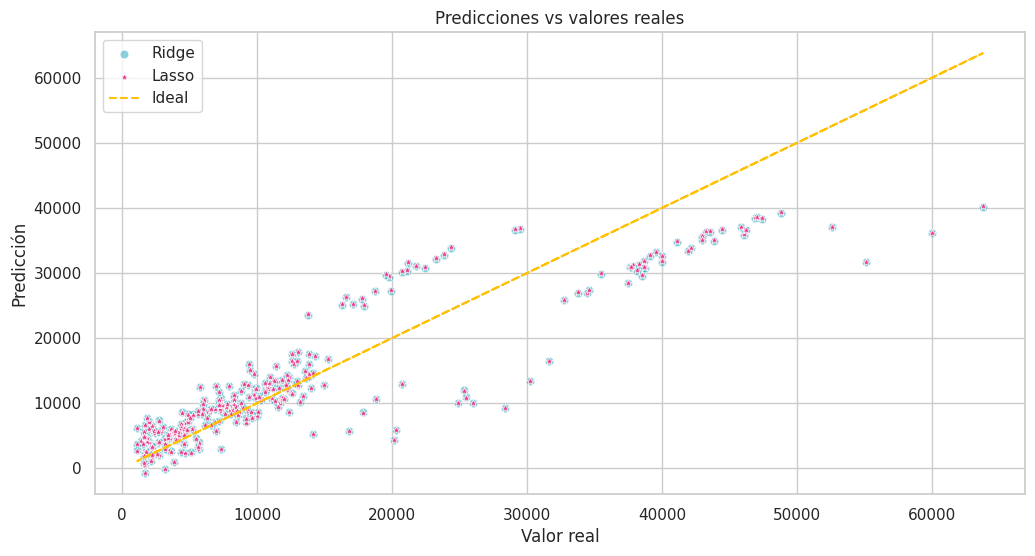

In [ ]:
# ------------------------------------------------------------------------------
# grafica comparativa
# ------------------------------------------------------------------------------

plt.figure(figsize=(12, 6))

# ridge
sns.scatterplot(
    x=y_test,
    y=ridge.predict(X_test_mlt),
    label='Ridge',
    color=_color_info,
    alpha=0.5)

# lasso
sns.scatterplot(
    x=y_test,
    y=lasso.predict(X_test_mlt),
    label='Lasso',
    color=_color_pink,
    marker="*")

# linea ideal
plt.plot(
    y_test,
    y_test,
    'k--',
    label='Ideal',
    color=_color_warning
    )

# titulos
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.legend()
plt.title("Predicciones vs valores reales")
plt.show()


El gráfico confirma que el rendimiento predictivo de los modelos Ridge y Lasso es prácticamente idéntico. Ninguna de las penalizaciones tuvo un impacto significativo en la precisión, lo que sugiere que la Regresión Lineal Múltiple (RLM) original ya era bastante efectiva

# 🎯 Conclusiones

La conclusión más importante es la diferencia entre el modelo polinomial y los modelos multivariables:

- El modelo polinomial de grado 5, con bmi, solo explica un 3.09% de la varianza ($\text{R}^2 \approx 0.03$) con un error promedio de casi $\$10,000$.
- En cambio, los modelos con multivariables (RLM, Ridge, Lasso) explican más del 80% de la varianza ($\text{R}^2 \approx 0.80$) y reducen el error promedio a aproximadamente $\$4,170$.

Esto demuestra que la inclusión de las variables predictoras correctas, como el indicador de fumador, es muchp más importante que aumentar la complejidad funcional de una sola variable débil.

## 🏆 Modelo Vencedor

El Modelo RLM (Base, con 5 variables) y el Modelo Lasso (L1, con 5 variables) son los modelos ganadores en términos de capacidad predictiva, con un mejor rendimiento en el conjunto de prueba.

Ambos modelos logran un $\text{R}^2$ de $\approx 0.80$ en datos de prueba.

# 📚 Liberias utilizadas para esta actividad

| Librería   | Alias/Módulo | Función Principal                                                                                                                                              |
| ---------- | ------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Pandas** | `pd` | Carga, manipulación y limpieza de datos usando **DataFrames**. Es la base de casi todo análisis. |
| **NumPy** | `np` | Soporte para **cálculos numéricos** eficientes con _arrays_ (vectores y matrices). Pandas se basa en NumPy. |
| **SciPy** | `stats` | Contiene funciones avanzadas para estadística, optimización e integración. Específicamente, el módulo `stats` se usa para pruebas de hipótesis y distribuciones. |
| **Matplotlib** | `plt` | Creación de gráficos **estáticos** y personalización detallada de visualizaciones. |
| **Seaborn** | `sns` | Creación de gráficos **estadísticos atractivos** de alto nivel, ideal para explorar distribuciones y relaciones. |
| **Tabulate** | `tabulate` | Formatea los datos (como listas o DataFrames) en **tablas con formato** para una mejor presentación en la consola o reportes. |
| `MinMaxScaler` | `sklearn.preprocessing` | **Normalización** de características (escalado) para que todos los valores estén en un rango específico (ej. entre 0 y 1). |
| `LabelEncoder` | `sklearn.preprocessing` | Codificación de **etiquetas categóricas** (variables dependientes) en valores numéricos. |
| `train_test_split` | `sklearn.model_selection` | División del conjunto de datos en subconjuntos de **entrenamiento y prueba**, esencial para evaluar el modelo. |
| `StandardScaler` | `sklearn.preprocessing` | **Estandarización** de características, escalando los datos para que tengan media $\\mu=0$ y desviación estándar $\\sigma=1$. |
| `PCA` | `sklearn.decomposition` | **Análisis de Componentes Principales**. Técnica de **reducción de dimensionalidad** para simplificar el conjunto de datos. |
| `KMeans` | `sklearn.cluster` | Algoritmo de **Clustering** (aprendizaje no supervisado) para agrupar datos similares en _clusters_ (segmentos). |
| `LinearRegression` | `sklearn.linear_model` | Algoritmo de **Regresión Lineal**, usado para predecir una variable continua. |
| `LogisticRegression` | `sklearn.linear_model` | Algoritmo de **Regresión Logística**, usado para predecir una variable binaria (clasificación). |
| `statsmodels.api` | `sm` | Permite ajustes de modelos estadísticos más **inferenciales y reportes detallados**, centrándose en la explicación del fenómeno (vs. la predicción pura de Scikit-learn). |
| `OrderedModel` | `statsmodels.miscmodels` | Modelo estadístico para la **regresión ordinal** (variables dependientes con orden natural, ej. "bajo, medio, alto"). |
| `mean_squared_error` (MSE) | Regresión | Mide el error promedio cuadrático entre las predicciones y los valores reales. |
| `r2_score` | Regresión | Mide la **proporción de la varianza** en la variable dependiente que es predecible por el modelo. |
| `mean_absolute_error` (MAE) | Regresión | Mide el error promedio en las mismas unidades que la variable de salida. |
| `accuracy_score` | Clasificación | Porcentaje de predicciones correctas totales. |
| `precision_score` | Clasificación | Porcentaje de positivos predichos correctamente (**True Positives**). |
| `recall_score` | Clasificación | Porcentaje de positivos reales que fueron identificados correctamente (**Sensibilidad**). |
| `f1_score` | Clasificación | Media armónica de Precisión y Recall (equilibrio entre ambas). |
| `classification_report` | Clasificación | Muestra Precision, Recall y F1-score por clase de manera tabular. |
| `confusion_matrix` | Clasificación | Tabla que muestra el rendimiento de un algoritmo de clasificación (TP, TN, FP, FN). |
| `roc_curve`, `auc` | Clasificación Binaria | Se utiliza para el **Análisis ROC** (Receiver Operating Characteristic) y calcula el **Área bajo la Curva (AUC)**, que mide qué tan bien el modelo distingue entre clases. |
| `PolynomialFeatures` | `sklearn.preprocessing` | **Genera características polinomiales** y términos de interacción a partir de las características existentes. Esto permite que un modelo lineal (como `LinearRegression`) modele relaciones no lineales. |
| `Lasso` | `sklearn.linear_model` | Un modelo de regresión lineal con **regularización L1**. Agrega una penalización a la suma del valor absoluto de los coeficientes, lo que fuerza a algunos coeficientes a ser cero, realizando efectivamente la **selección de características**. |
| `Ridge` | `sklearn.linear_model` | Un modelo de regresión lineal con **regularización L2**. Agrega una penalización a la suma de los cuadrados de los coeficientes, lo que ayuda a prevenir el sobreajuste al reducir la magnitud de los coeficientes (pero sin hacerlos cero). |